# Detecção de Fraudes em Transações de Cartão de Crédito

**Autor:** João Alfredo de Sousa Siqueira  
**Data:** Abril/2026  
**Dataset:** [Credit Card Transactions Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/kartik2112/fraud-detection) (Licença ODbL)

Este projeto segue a metodologia **CRISP-DM**, organizando o trabalho em seis fases: entendimento do negócio, entendimento dos dados, preparação dos dados, modelagem, avaliação e implantação.

# 1. Entendimento do Negócio

A primeira fase do CRISP-DM define o problema sob a ótica do negócio antes de tocar em qualquer dado. O que está em jogo, qual o objetivo, e como vamos medir sucesso de uma forma que faça sentido para quem toma decisões.

## 1.1 Contexto do Problema

O mercado de pagamentos digitais brasileiro movimenta trilhões de reais por ano. Empresas como **PicPay**, **BoaVista** e **Travelex** lidam diariamente com o desafio de identificar transações fraudulentas em tempo real, sem bloquear transações legítimas e sem impactar a experiência do cliente.

Regras manuais como *"bloquear transações acima de R$ X em outro estado"* não escalam: fraudadores se adaptam rapidamente e qualquer regra fixa se torna obsoleta. Um modelo de machine learning que aprende padrões comportamentais diretamente dos dados é fundamentalmente superior, e é o que este projeto propõe.

## 1.2 Objetivo do Projeto

Construir um modelo preditivo capaz de identificar transações fraudulentas com alta taxa de **Recall**, priorizando não deixar fraudes passarem, sem comprometer demasiadamente a Precisão, e com saldo financeiro líquido positivo para o negócio.

O sucesso do projeto não é medido apenas por métricas estatísticas, mas pelo impacto financeiro real: quanto dinheiro o modelo economiza após descontar o custo dos bloqueios indevidos.

## 1.3 Por que não usar Acurácia como métrica?

Com **99,42%** das transações sendo legítimas, um modelo que classifica *tudo* como legítimo atingiria 99,42% de Acurácia e seria completamente inútil, pois nunca detectaria uma fraude.

A métrica correta aqui é o **AUC-ROC** combinado com **F1-Score**, analisando o trade-off entre Precisão e Recall:

| Métrica | O que mede |
|---------|-----------|
| **Recall** | De todas as fraudes reais, quantas o modelo encontrou? |
| **Precision** | De todos os alertas de fraude, quantos eram fraude de verdade? |
| **F1-Score** | Média harmônica entre Precisão e Recall |
| **AUC-ROC** | Capacidade geral de separar as classes |

## 1.4 Definição de Sucesso

Um banco prefere bloquear algumas transações legítimas a deixar fraudes passarem, então **Recall alto é prioridade**. Mas legítimas bloqueadas em excesso geram custo operacional e insatisfação do cliente. O modelo ideal equilibra os dois lados.

O critério de sucesso final deste projeto é um **saldo financeiro líquido positivo**: o valor em fraudes evitadas menos o custo das transações legítimas bloqueadas indevidamente. Essa é a métrica que conversa diretamente com o negócio e que vai guiar a escolha do modelo na fase de avaliação.

## 1.5 Configuração do Ambiente

Importação das bibliotecas e definição dos parâmetros visuais usados ao longo do projeto.

In [1]:
# ===== Bibliotecas padrao =====
import os
import time
import warnings
from collections import Counter

# ===== Manipulacao e analise de dados =====
import pandas as pd
import numpy as np

# ===== Visualizacao =====
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Estatistica =====
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ===== Pre-processamento e validacao =====
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     RandomizedSearchCV, learning_curve)

# ===== Modelos =====
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

# ===== Balanceamento de classes =====
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# ===== Metricas =====
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay, f1_score, precision_score, recall_score,
                             precision_recall_curve, average_precision_score)

# ===== Interpretabilidade =====
import shap

# ===== Configuracoes =====
warnings.filterwarnings('ignore')
%matplotlib inline

mpl.style.use('ggplot')
mpl.rcParams['axes.facecolor']  = 'white'
mpl.rcParams['axes.linewidth']  = 1
mpl.rcParams['xtick.color']     = 'black'
mpl.rcParams['ytick.color']     = 'black'
mpl.rcParams['grid.color']      = 'lightgray'
mpl.rcParams['figure.dpi']      = 150
mpl.rcParams['axes.grid']       = True
mpl.rcParams['font.size']       = 12

color_palette = ['#023047', '#e85d04', '#0077b6', '#ff8200', '#0096c7', '#ff9c33']
sns.set_palette(sns.color_palette(color_palette))

RANDOM_STATE = 42

# cria a pasta de imagens para salvar os graficos
os.makedirs('images', exist_ok=True)

print('Imports e configuracoes OK')

Imports e configuracoes OK


C:\Users\xuao\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Entendimento dos Dados

Com o problema de negócio definido, partimos para conhecer os dados a fundo. Esta fase combina exploração visual com diagnóstico estatístico formal, construindo a base de evidências que vai justificar cada decisão de preparação e modelagem.

## 2.1 Carregamento dos Dados

In [2]:
# leitura dos arquivos CSV
train = pd.read_csv('fraudTrain.csv')
test  = pd.read_csv('fraudTest.csv')

print('Treino:', train.shape)
print('Teste :', test.shape)


Treino: (1296675, 23)
Teste : (555719, 23)


## 2.2 Visão Geral do Dataset

Primeira inspeção da estrutura: volume de registros, colunas disponíveis e tipos de dados.

In [3]:
# primeiras visualizações
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

print('INFORMAÇÕES GERAIS')
print(train.info())

print('\nVALORES NULOS')
print(train.isnull().sum())

print('\nESTATÍSTICAS DESCRITIVAS')
print(train.describe())


INFORMAÇÕES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14 

> **O que isso diz para o negócio**
>
> O dataset reúne mais de 1,8 milhão de transações com informações de valor, localização, estabelecimento e perfil do titular. É um volume robusto que permite ao modelo aprender padrões comportamentais reais, algo impossível com regras manuais.

## 2.3 Análise do Desbalanceamento

Em detecção de fraude, o desbalanceamento entre classes é a primeira característica a investigar, pois define toda a estratégia de modelagem.

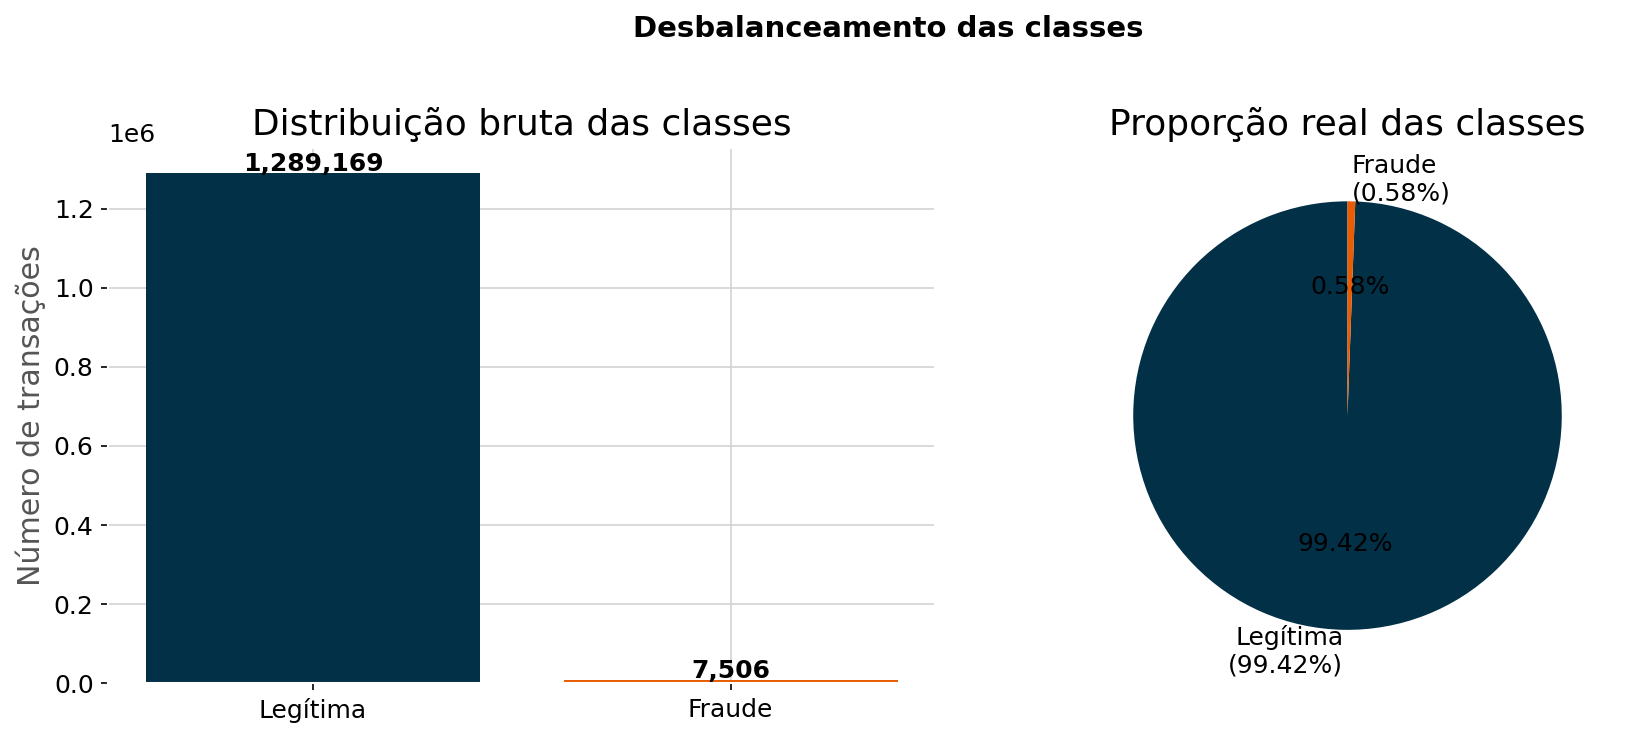

In [4]:
# visualização do desbalanceamento
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contagem = train['is_fraud'].value_counts()

# gráfico de barras da distribuição bruta
axes[0].bar(['Legítima', 'Fraude'],
            [contagem[0], contagem[1]],
            color=['#023047', '#e85d04'])
axes[0].set_title('Distribuição bruta das classes')
axes[0].set_ylabel('Número de transações')
for i, v in enumerate([contagem[0], contagem[1]]):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# gráfico de pizza da proporção real
axes[1].pie([contagem[0], contagem[1]],
            labels=[f'Legítima\n({contagem[0]/len(train)*100:.2f}%)',
                    f'Fraude\n({contagem[1]/len(train)*100:.2f}%)'],
            colors=['#023047', '#e85d04'],
            autopct='%1.2f%%',
            startangle=90)
axes[1].set_title('Proporção real das classes')

plt.suptitle('Desbalanceamento das classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/01_desbalanceamento.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> Apenas 0,58% das transações são fraudes. Esse desbalanceamento severo significa que o modelo precisa de tratamento especial para não simplesmente ignorar a classe minoritária. Para o negócio, é a confirmação de que fraude é um evento raro mas caro, e que cada acerto importa.

## 2.4 Valor das Transações: Legítimas vs Fraudulentas

O valor da transação é a variável mais intuitiva para investigar primeiro: fraudadores tendem a maximizar o ganho por transação.

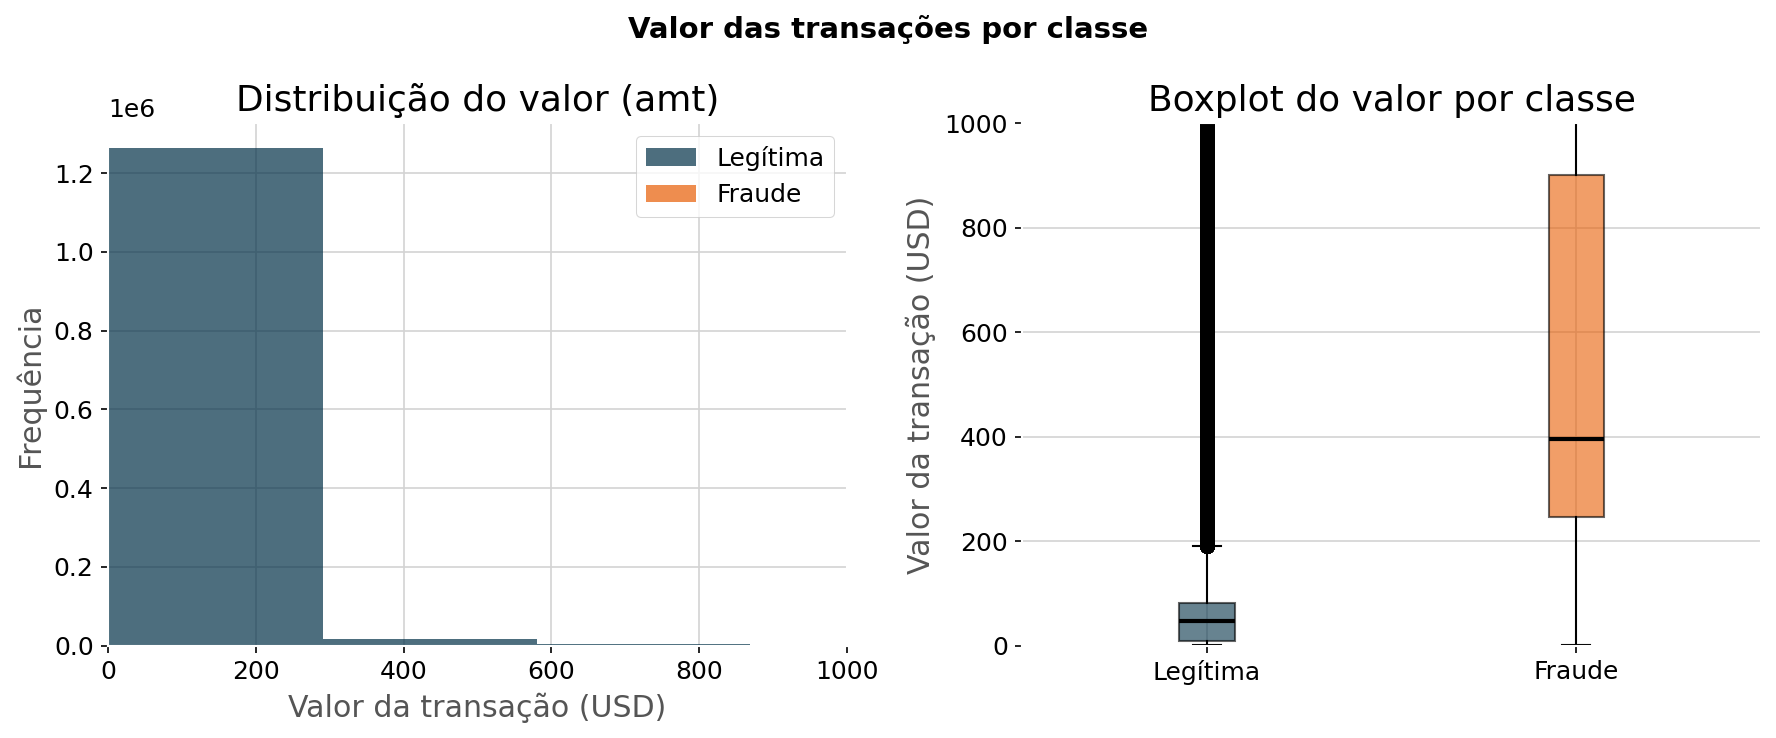

Média      Legítima : USD 67.67
Média      Fraude   : USD 531.32
Mediana    Legítima : USD 47.28
Mediana    Fraude   : USD 396.50


In [5]:
# análise do valor das transações por classe
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

legitimas    = train[train['is_fraud'] == 0]['amt']
fraudulentas = train[train['is_fraud'] == 1]['amt']

# histogramas sobrepostos para comparar as distribuições
axes[0].hist(legitimas,    bins=100, color='#023047', alpha=0.7, label='Legítima')
axes[0].hist(fraudulentas, bins=100, color='#e85d04', alpha=0.7, label='Fraude')
axes[0].set_xlim(0, 1000)
axes[0].set_title('Distribuição do valor (amt)')
axes[0].set_xlabel('Valor da transação (USD)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# boxplot para comparar a dispersão e os outliers
bp = axes[1].boxplot([legitimas, fraudulentas],
                     labels=['Legítima', 'Fraude'],
                     patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#023047'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e85d04'); bp['boxes'][1].set_alpha(0.6)
axes[1].set_title('Boxplot do valor por classe')
axes[1].set_ylabel('Valor da transação (USD)')
axes[1].set_ylim(0, 1000)

plt.suptitle('Valor das transações por classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/02_valor_transacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Média      Legítima : USD {legitimas.mean():.2f}')
print(f'Média      Fraude   : USD {fraudulentas.mean():.2f}')
print(f'Mediana    Legítima : USD {legitimas.median():.2f}')
print(f'Mediana    Fraude   : USD {fraudulentas.median():.2f}')


> **O que isso diz para o negócio**
>
> Fraudes têm valor médio de USD 531 contra USD 67 das legítimas, quase 8 vezes maior. Acima de USD 500, mais de 23% das transações são fraudulentas. Isso significa que transações de alto valor merecem escrutínio reforçado, e que o valor sozinho já é um sinal forte de risco.

## 2.5 Categorias de Estabelecimento com Maior Taxa de Fraude

Nem todo tipo de comércio tem o mesmo risco. Investigar a taxa de fraude por categoria revela onde os fraudadores concentram a atividade.

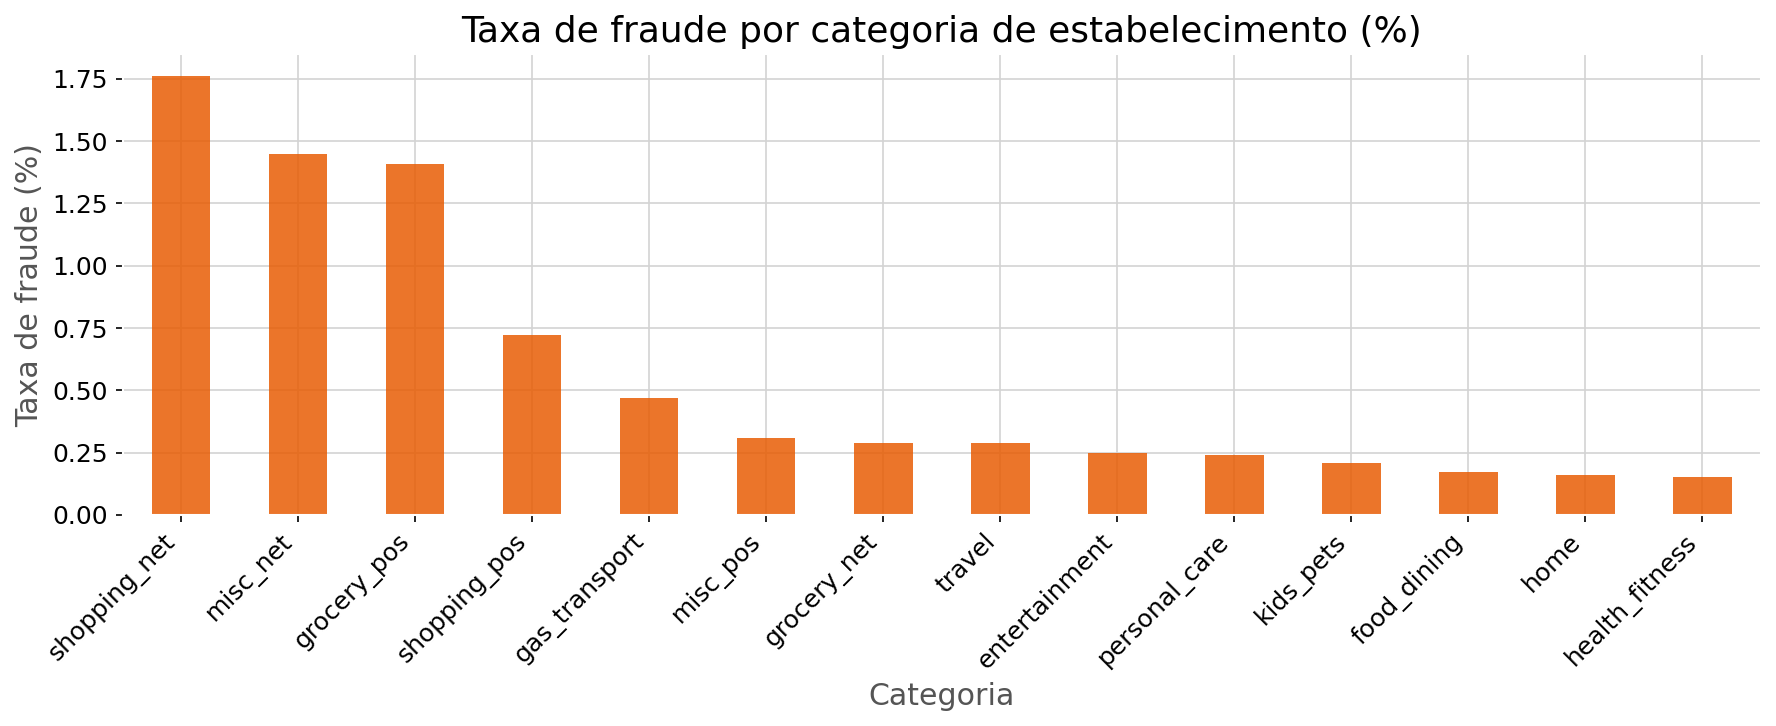

category
shopping_net     1.76
misc_net         1.45
grocery_pos      1.41
shopping_pos     0.72
gas_transport    0.47
misc_pos         0.31
grocery_net      0.29
travel           0.29
entertainment    0.25
personal_care    0.24
kids_pets        0.21
food_dining      0.17
home             0.16
health_fitness   0.15
Name: is_fraud, dtype: float64


In [6]:
# análise da taxa de fraude por categoria de estabelecimento
fraude_por_categoria = (train.groupby('category')['is_fraud']
                             .mean()
                             .sort_values(ascending=False)
                             .mul(100)
                             .round(2))

plt.figure(figsize=(12, 5))
fraude_por_categoria.plot(kind='bar', color='#e85d04', alpha=0.85)
plt.title('Taxa de fraude por categoria de estabelecimento (%)')
plt.ylabel('Taxa de fraude (%)')
plt.xlabel('Categoria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/03_fraude_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

print(fraude_por_categoria)


> **O que isso diz para o negócio**
>
> Categorias online como shopping_net (1,75%) e misc_net (1,44%) lideram as taxas de fraude, justamente por não exigirem verificação física do cartão. Para o negócio, isso sugere camadas extras de autenticação em compras online dessas categorias.

## 2.6 Fraude por Gênero e Faixa de Valor

Cruzamento de variáveis demográficas e de valor para entender se há perfis de maior risco.

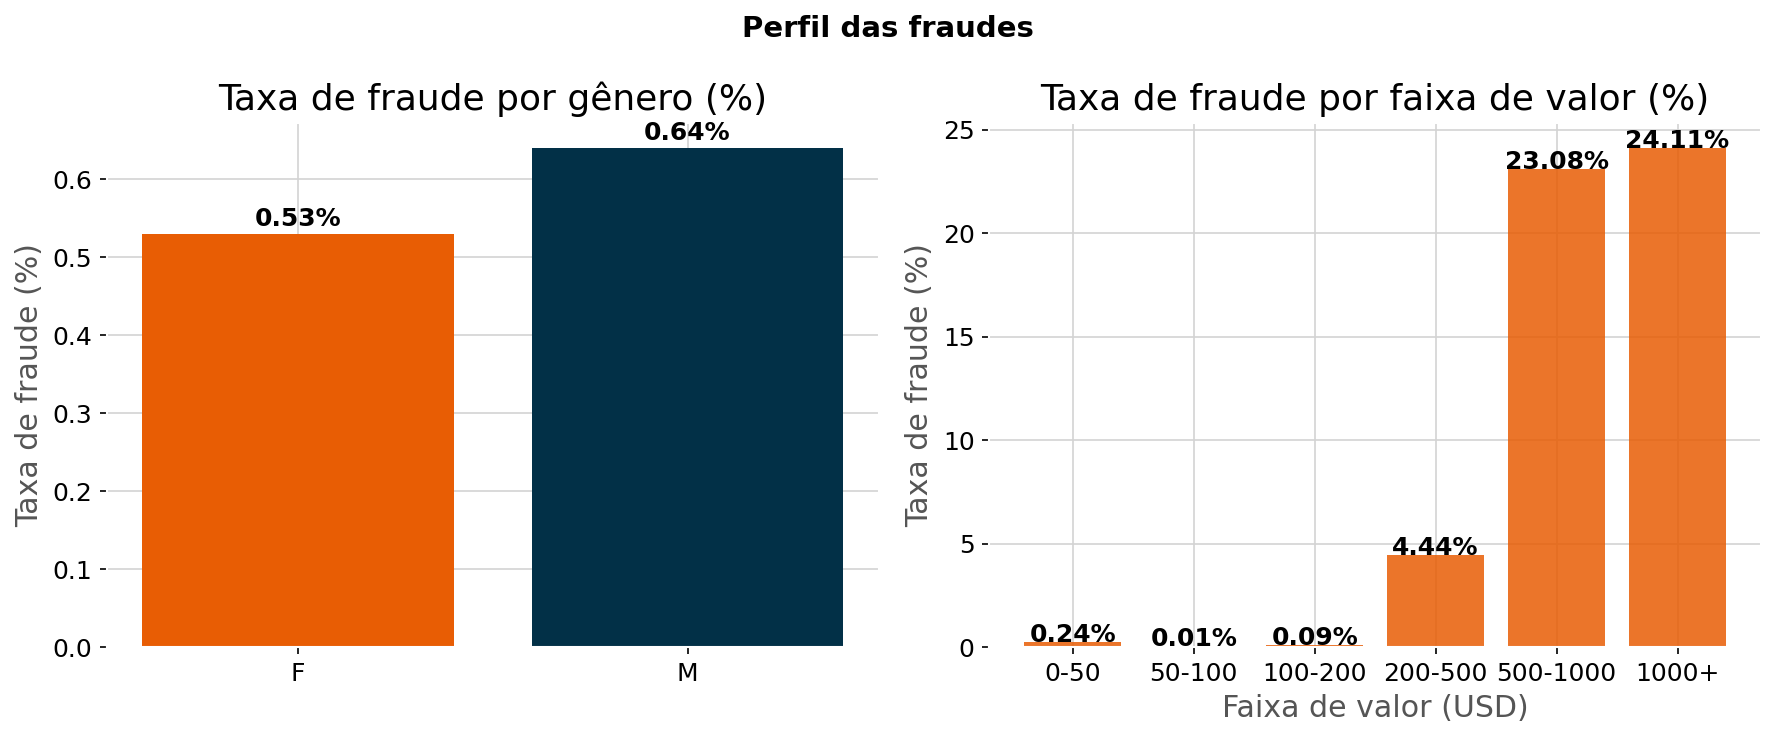

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# taxa de fraude por gênero
fraude_genero = (train.groupby('gender')['is_fraud']
                      .mean().mul(100).round(2))
axes[0].bar(fraude_genero.index, fraude_genero.values, color=['#e85d04', '#023047'])
axes[0].set_title('Taxa de fraude por gênero (%)')
axes[0].set_ylabel('Taxa de fraude (%)')
for i, v in enumerate(fraude_genero.values):
    axes[0].text(i, v + 0.01, f'{v}%', ha='center', fontweight='bold')

bins        = [0, 50, 100, 200, 500, 1000, 99999]
labels_bins = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
train['faixa_valor'] = pd.cut(train['amt'], bins=bins, labels=labels_bins)

# taxa de fraude por faixa de valor
fraude_faixa = (train.groupby('faixa_valor', observed=True)['is_fraud']
                     .mean().mul(100).round(2))
axes[1].bar(fraude_faixa.index, fraude_faixa.values, color='#e85d04', alpha=0.85)
axes[1].set_title('Taxa de fraude por faixa de valor (%)')
axes[1].set_ylabel('Taxa de fraude (%)')
axes[1].set_xlabel('Faixa de valor (USD)')
for i, v in enumerate(fraude_faixa.values):
    axes[1].text(i, v + 0.02, f'{v}%', ha='center', fontweight='bold')

plt.suptitle('Perfil das fraudes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/04_perfil_fraudes.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> A diferença de fraude entre gêneros é pequena (0,64% homens vs 0,53% mulheres), insuficiente para ser um preditor isolado. A faixa de valor continua sendo o sinal dominante, reforçando o achado da seção 2.4.

## 2.7 Correlação das Variáveis com Fraude

A análise de correlação começa pelo coeficiente de Pearson, que mede relações lineares, e é complementada pelo coeficiente de Spearman, mais robusto para as variáveis assimétricas que caracterizam dados financeiros.

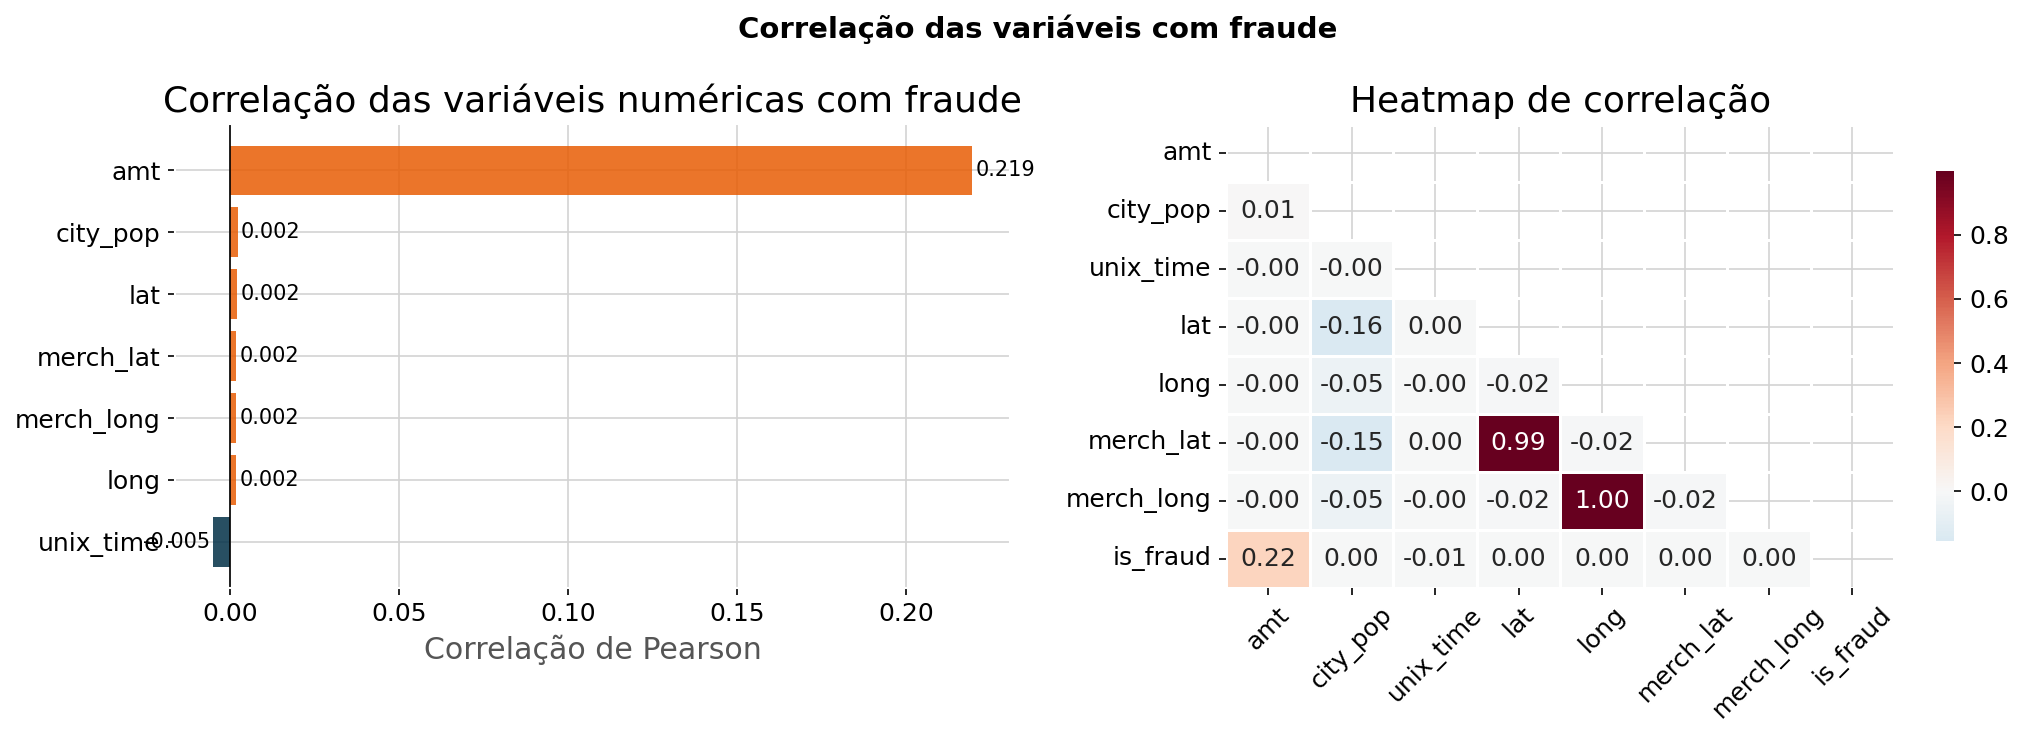

Top 3 variáveis mais correlacionadas com fraude:
amt         0.22
unix_time   0.01
city_pop    0.00
Name: is_fraud, dtype: float64


In [8]:
#  1. Heatmap de correlação das variáveis numéricas com is_fraud 
numericas = ['amt', 'city_pop', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long']
corr_fraude = train[numericas + ['is_fraud']].corr()['is_fraud'].drop('is_fraud').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# barplot de correlação com is_fraud
cores_corr = ['#e85d04' if v > 0 else '#023047' for v in corr_fraude.values]
axes[0].barh(corr_fraude.index, corr_fraude.values, color=cores_corr, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação das variáveis numéricas com fraude')
axes[0].set_xlabel('Correlação de Pearson')
for i, v in enumerate(corr_fraude.values):
    axes[0].text(v + (0.001 if v >= 0 else -0.001), i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=10)

# heatmap completo das variáveis numéricas
corr_matrix = train[numericas + ['is_fraud']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Heatmap de correlação')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Correlação das variáveis com fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05a_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 variáveis mais correlacionadas com fraude:')
print(corr_fraude.abs().sort_values(ascending=False).head(3))


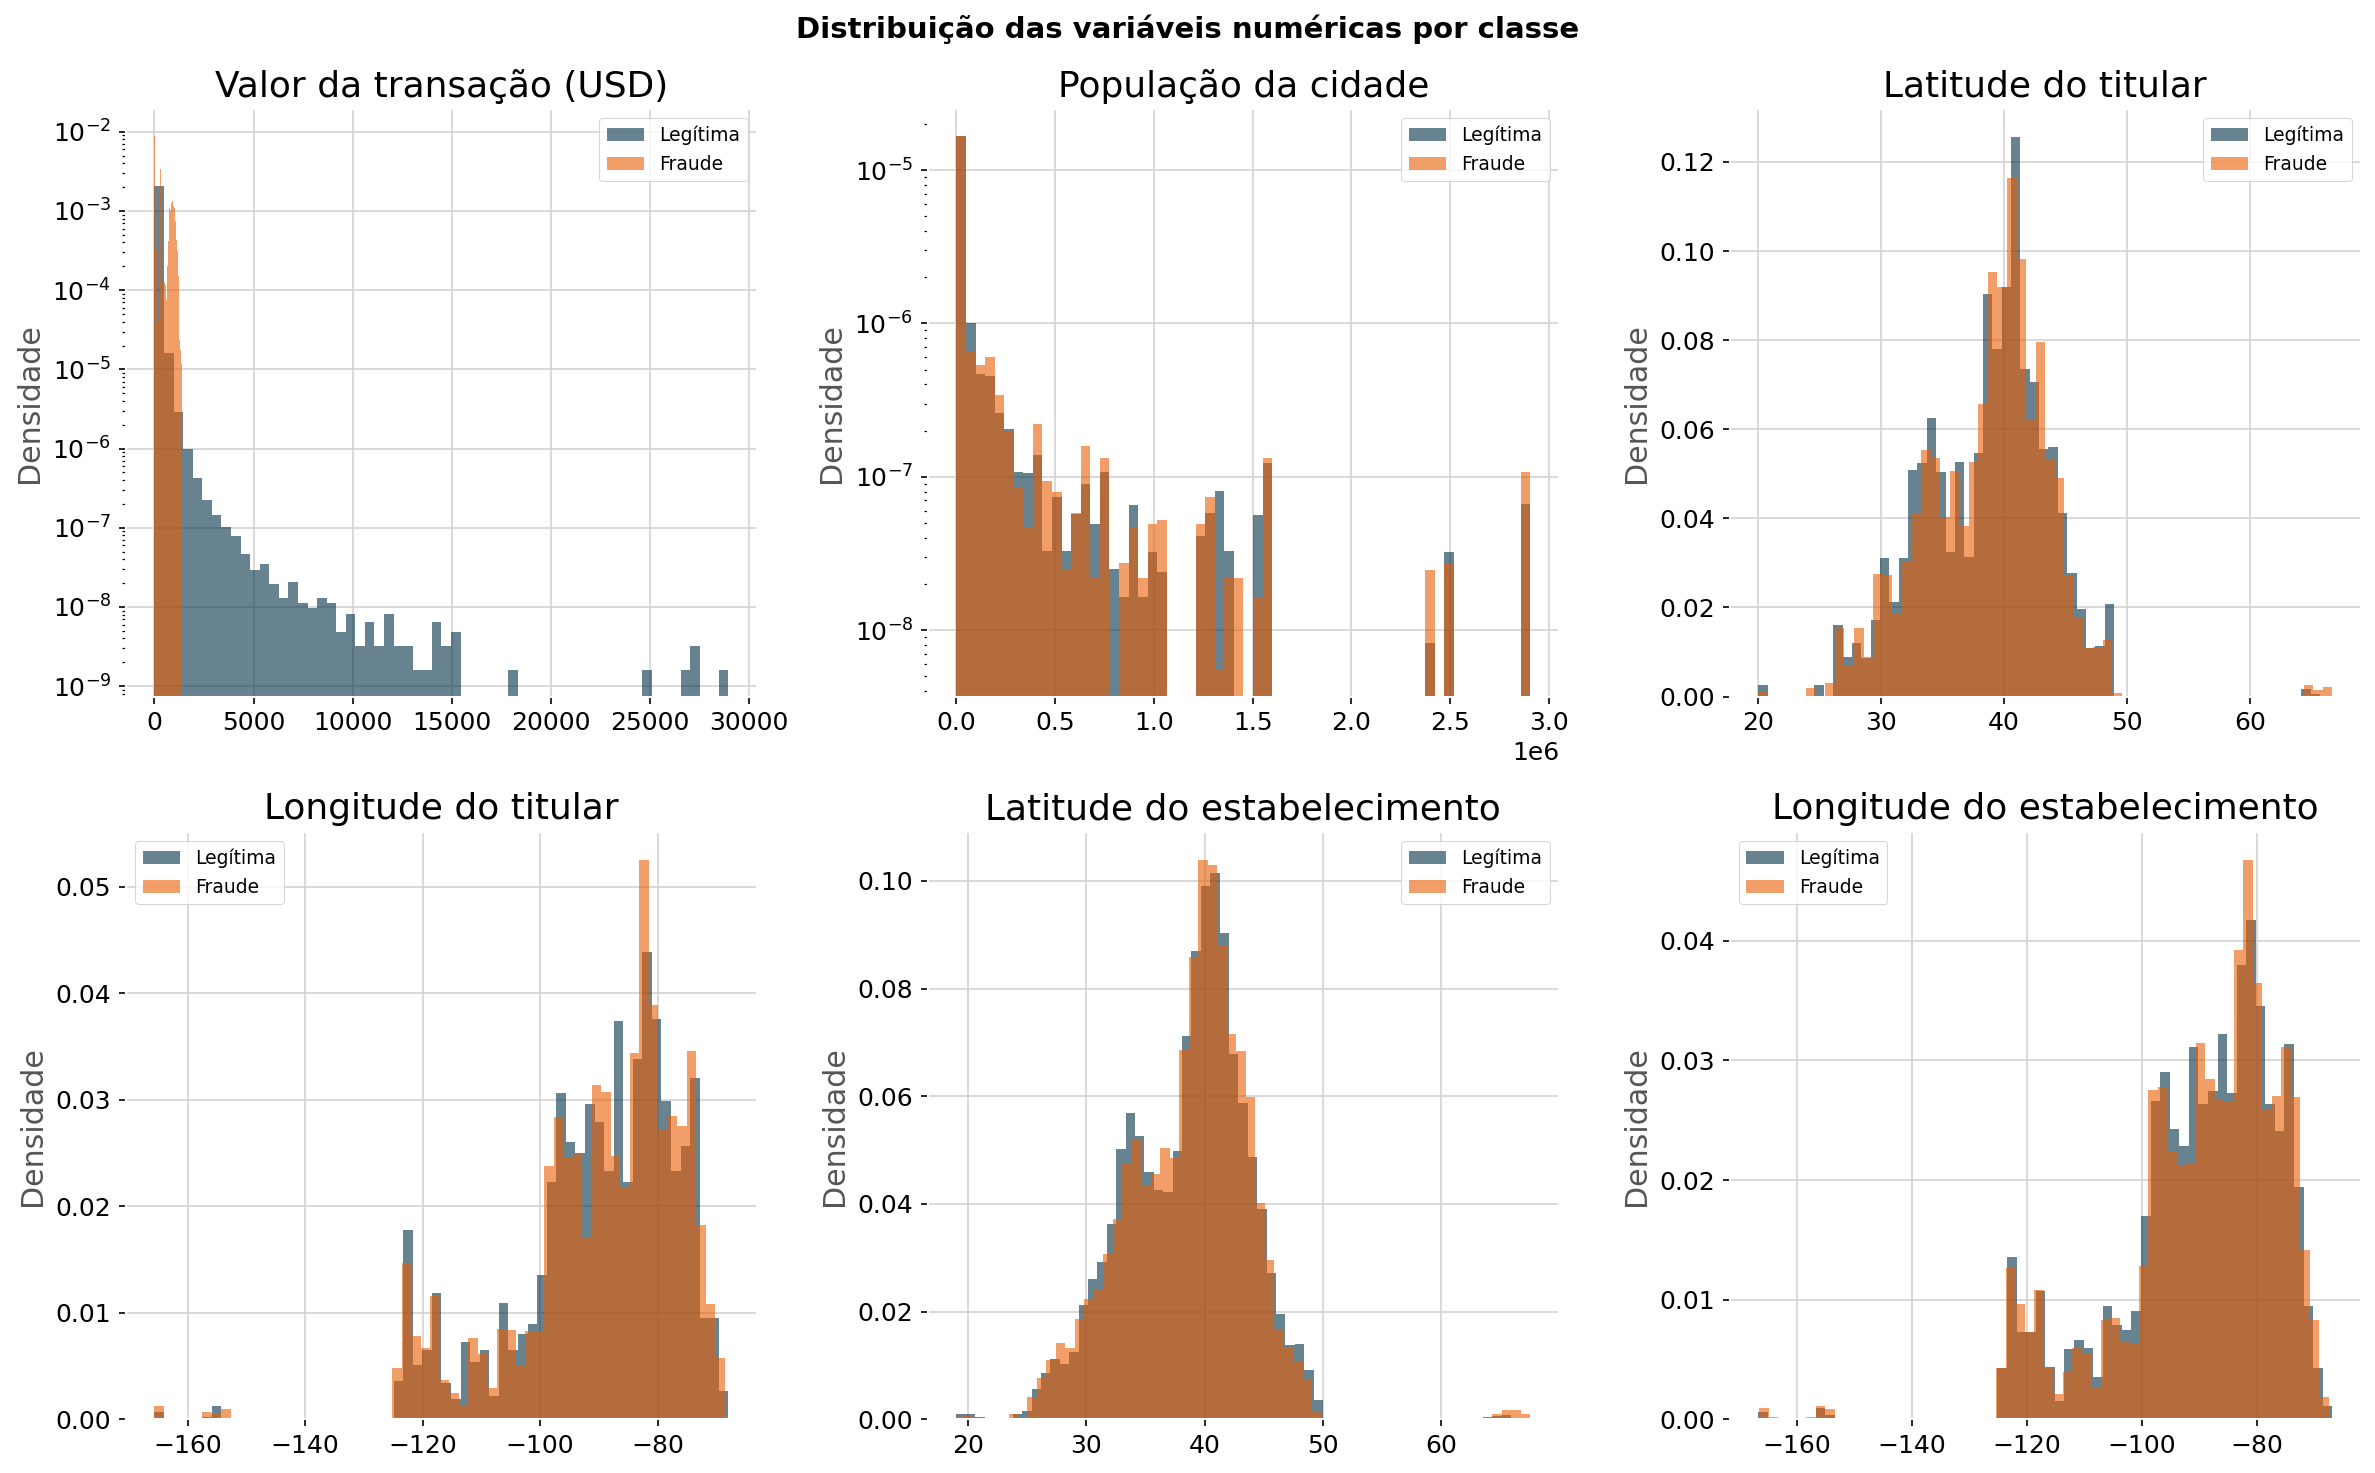

In [9]:
#  2. Distribuição das variáveis numéricas por classe (fraude vs legítima) 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

variaveis_plot = [
    ('amt',      'Valor da transação (USD)',     True),
    ('city_pop', 'População da cidade',           True),
    ('lat',      'Latitude do titular',           False),
    ('long',     'Longitude do titular',          False),
    ('merch_lat','Latitude do estabelecimento',   False),
    ('merch_long','Longitude do estabelecimento', False),
]

for ax, (col, label, log_scale) in zip(axes, variaveis_plot):
    legitimas_v    = train[train['is_fraud'] == 0][col]
    fraudulentas_v = train[train['is_fraud'] == 1][col]
    ax.hist(legitimas_v,    bins=60, alpha=0.6, label='Legítima',
            color='#023047', density=True)
    ax.hist(fraudulentas_v, bins=60, alpha=0.6, label='Fraude',
            color='#e85d04', density=True)
    ax.set_title(label)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=9)
    if log_scale:
        ax.set_yscale('log')

plt.suptitle('Distribuição das variáveis numéricas por classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05b_distribuicao_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()


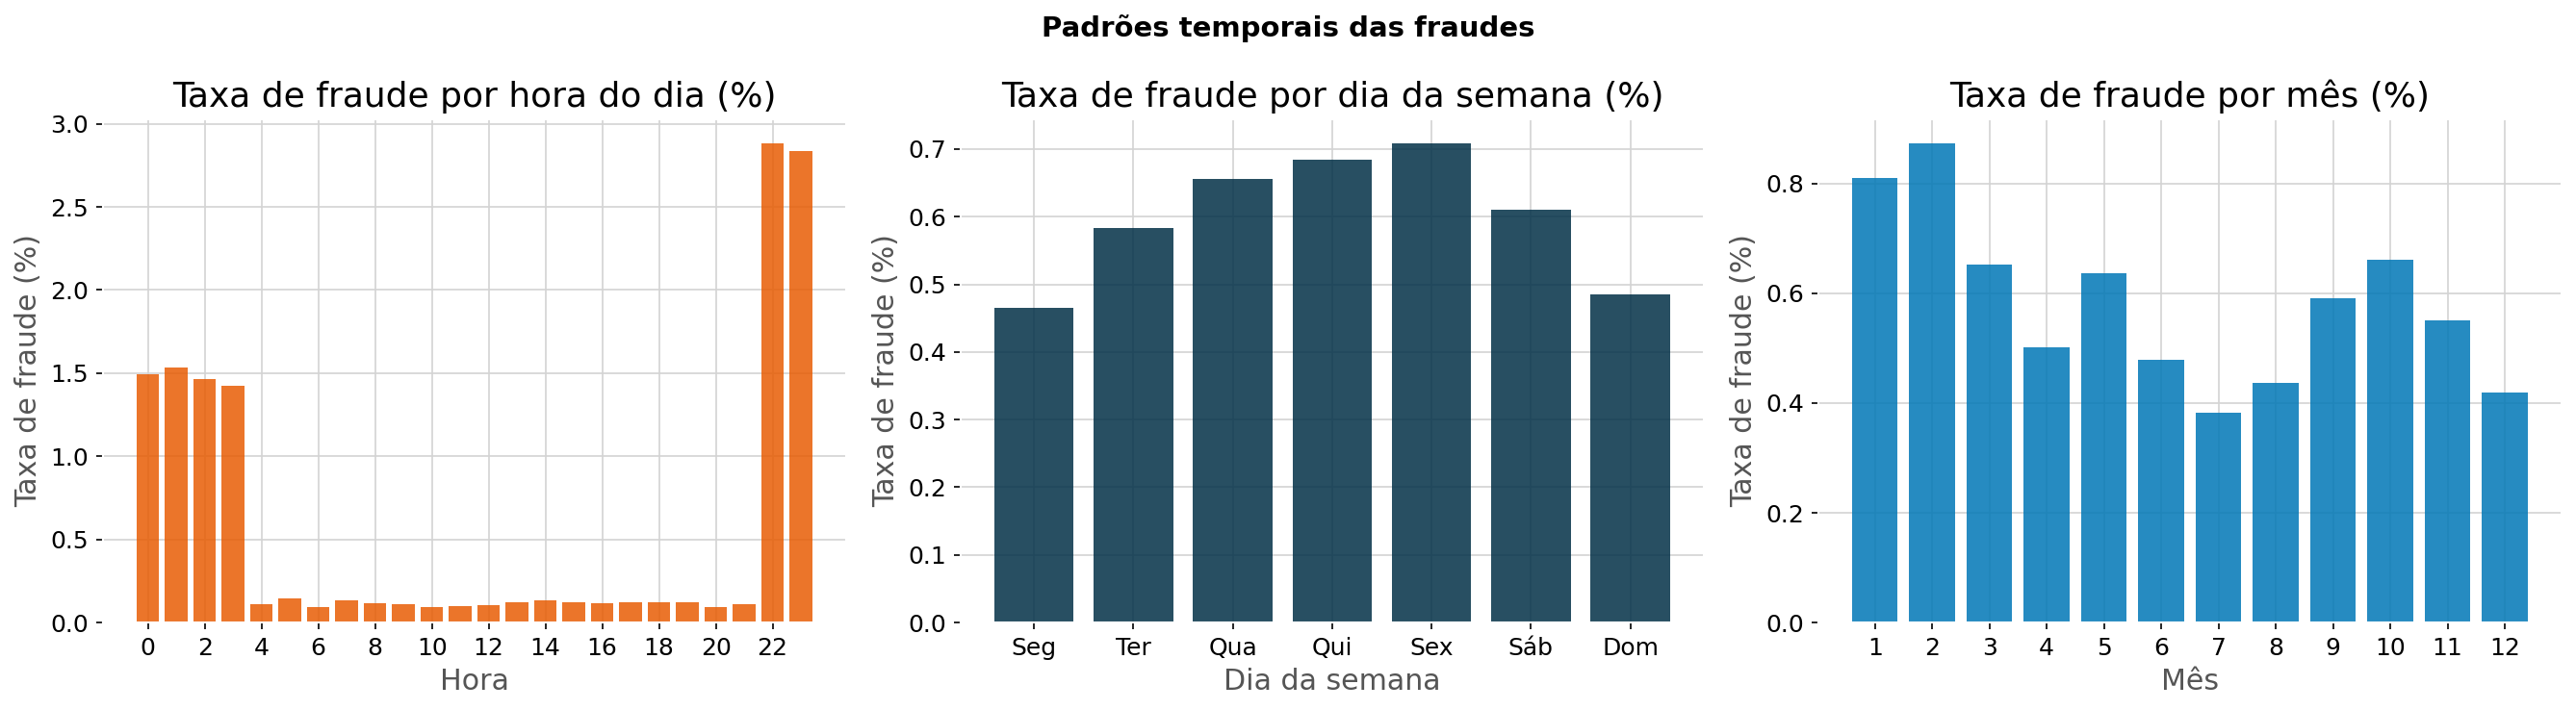

In [10]:
#  3. Padrões temporais: hora do dia e dia da semana vs fraude 
train_temp = train.copy()
train_temp['hora']      = pd.to_datetime(train['trans_date_trans_time']).dt.hour
train_temp['dia_semana']= pd.to_datetime(train['trans_date_trans_time']).dt.dayofweek
train_temp['mes']       = pd.to_datetime(train['trans_date_trans_time']).dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# taxa de fraude por hora
fraude_hora = (train_temp.groupby('hora')['is_fraud']
                          .mean().mul(100).reset_index())
axes[0].bar(fraude_hora['hora'], fraude_hora['is_fraud'],
            color='#e85d04', alpha=0.85)
axes[0].set_title('Taxa de fraude por hora do dia (%)')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Taxa de fraude (%)')
axes[0].set_xticks(range(0, 24, 2))

# taxa de fraude por dia da semana
dias_map = {0:'Seg', 1:'Ter', 2:'Qua', 3:'Qui', 4:'Sex', 5:'Sáb', 6:'Dom'}
fraude_dia = (train_temp.groupby('dia_semana')['is_fraud']
                         .mean().mul(100).reset_index())
fraude_dia['dia_nome'] = fraude_dia['dia_semana'].map(dias_map)
axes[1].bar(fraude_dia['dia_nome'], fraude_dia['is_fraud'],
            color='#023047', alpha=0.85)
axes[1].set_title('Taxa de fraude por dia da semana (%)')
axes[1].set_xlabel('Dia da semana')
axes[1].set_ylabel('Taxa de fraude (%)')

# taxa de fraude por mês
fraude_mes = (train_temp.groupby('mes')['is_fraud']
                         .mean().mul(100).reset_index())
axes[2].bar(fraude_mes['mes'], fraude_mes['is_fraud'],
            color='#0077b6', alpha=0.85)
axes[2].set_title('Taxa de fraude por mês (%)')
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Taxa de fraude (%)')
axes[2].set_xticks(range(1, 13))

plt.suptitle('Padrões temporais das fraudes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05c_padroes_temporais.png', dpi=150, bbox_inches='tight')
plt.show()


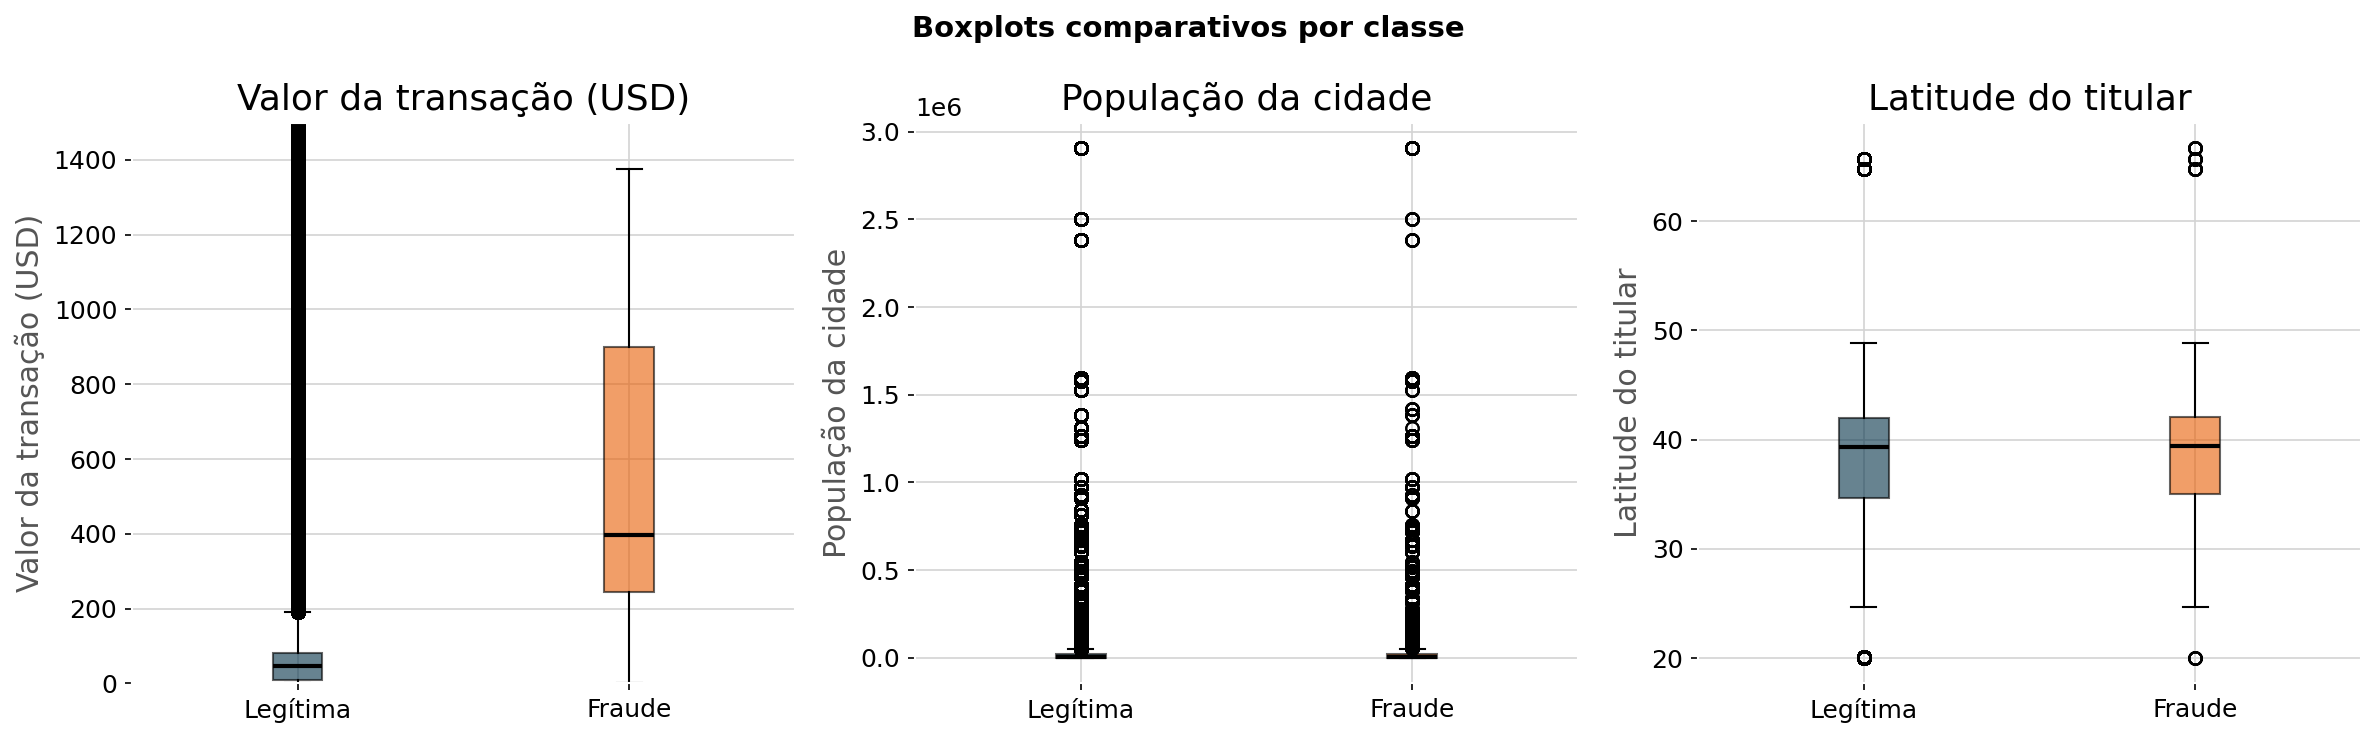

In [11]:
#  4. Boxplots comparativos: variáveis numéricas por classe 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label) in zip(axes, [
    ('amt',      'Valor da transação (USD)'),
    ('city_pop', 'População da cidade'),
    ('lat',      'Latitude do titular'),
]):
    data_plot = [
        train[train['is_fraud'] == 0][col].dropna(),
        train[train['is_fraud'] == 1][col].dropna()
    ]
    bp = ax.boxplot(data_plot, labels=['Legítima', 'Fraude'],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#023047')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#e85d04')
    bp['boxes'][1].set_alpha(0.6)
    ax.set_title(label)
    ax.set_ylabel(label)
    if col == 'amt':
        ax.set_ylim(0, 1500)

plt.suptitle('Boxplots comparativos por classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05d_boxplots_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> Os padrões temporais saltam aos olhos: fraudes se concentram fortemente entre meia-noite e 4h da manhã. Isso valida a criação de uma feature de hora do dia e sugere monitoramento reforçado na madrugada, quando o titular legítimo provavelmente está dormindo.

### 2.7.1 Correlação de Spearman e Threshold Formal

Pearson mede correlação linear e assume distribuição aproximadamente normal. Variáveis como `amt` e `city_pop` são altamente assimétricas, o que distorce o coeficiente de Pearson. Spearman opera sobre os rankings das observações, sendo robusto a assimetria e outliers, e captura relações monótonas mesmo quando não são lineares.

Adotamos um threshold formal: qualquer par com correlação de Spearman acima de **0.85** entra em análise para remoção, transformando uma decisão subjetiva em critério auditável.

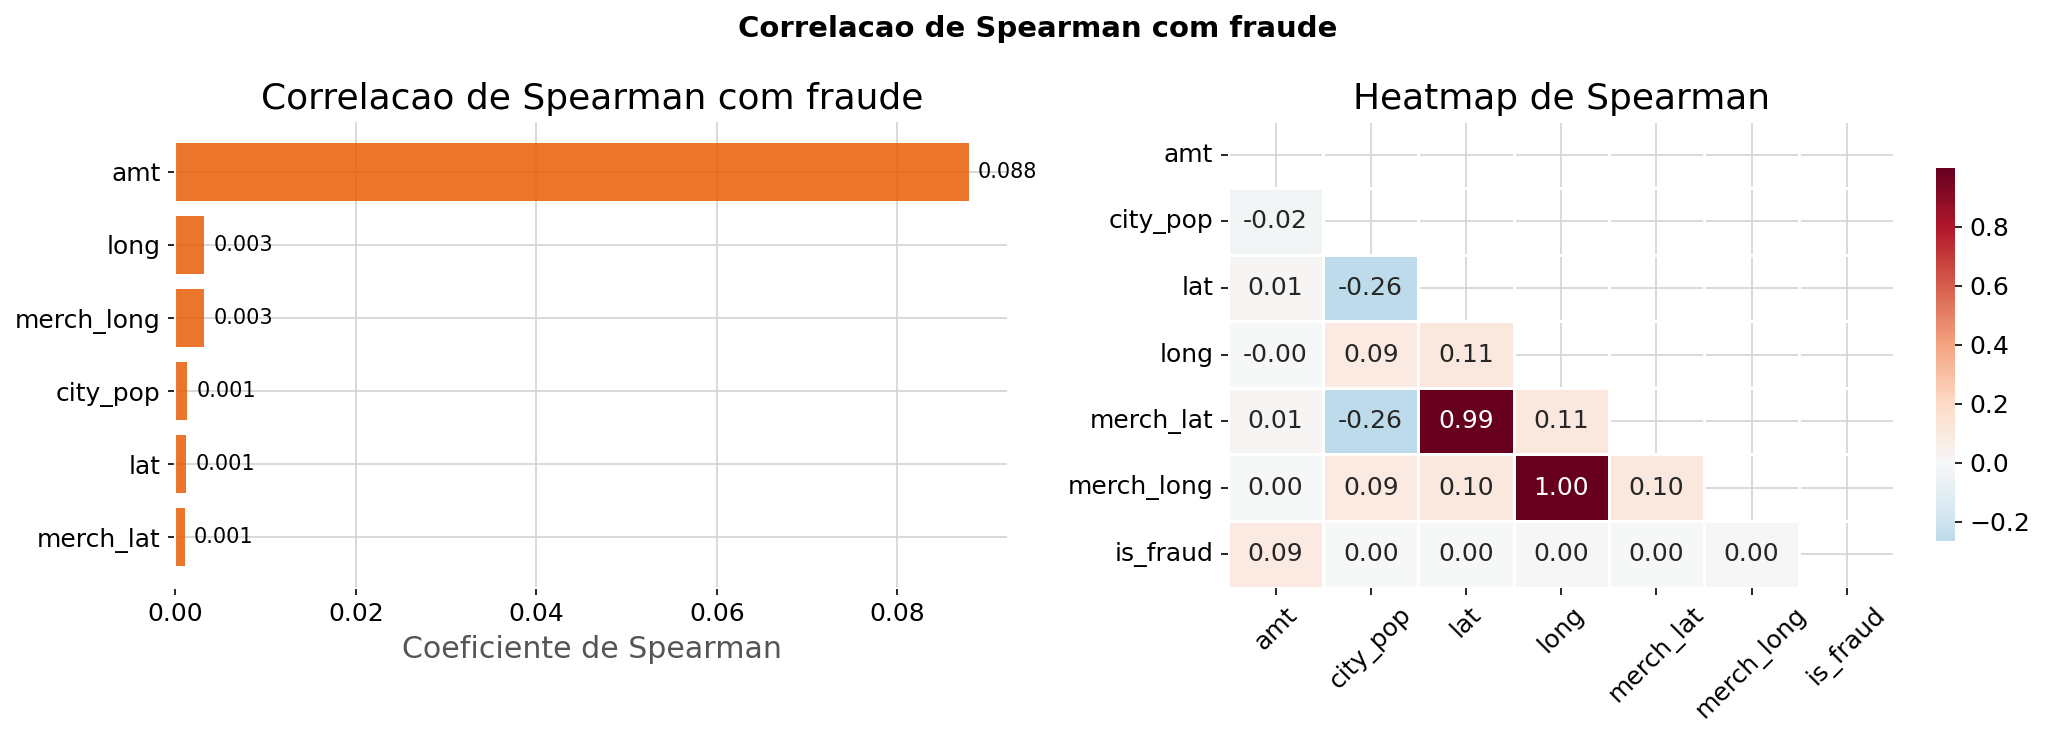

Pares com |Spearman| >= 0.85 (candidatos a remocao):
     var_a var_b  spearman_abs
merch_long  long          1.00
 merch_lat   lat          0.99


In [12]:
# correlacao de Spearman das variaveis numericas com is_fraud
numericas = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']

spearman_fraude = (
    train[numericas + ['is_fraud']]
    .corr(method='spearman')['is_fraud']
    .drop('is_fraud')
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# barplot Spearman vs is_fraud
cores = ['#e85d04' if v > 0 else '#023047' for v in spearman_fraude.values]
axes[0].barh(spearman_fraude.index, spearman_fraude.values, color=cores, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlacao de Spearman com fraude')
axes[0].set_xlabel('Coeficiente de Spearman')
for i, v in enumerate(spearman_fraude.values):
    axes[0].text(v + (0.001 if v >= 0 else -0.001), i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=10)

# heatmap Spearman completo entre as variaveis numericas
spearman_matrix = train[numericas + ['is_fraud']].corr(method='spearman')
mask = np.triu(np.ones_like(spearman_matrix, dtype=bool))
sns.heatmap(spearman_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Heatmap de Spearman')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Correlacao de Spearman com fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05e_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

# pares com correlacao de Spearman acima do threshold
THRESHOLD_CORR = 0.85
pares_altos = (
    spearman_matrix.abs()
    .where(np.tril(np.ones_like(spearman_matrix, dtype=bool), k=-1))
    .stack()
    .reset_index()
)
pares_altos.columns = ['var_a', 'var_b', 'spearman_abs']
pares_altos = pares_altos[pares_altos['spearman_abs'] >= THRESHOLD_CORR].sort_values('spearman_abs', ascending=False)

print(f'Pares com |Spearman| >= {THRESHOLD_CORR} (candidatos a remocao):')
if pares_altos.empty:
    print('Nenhum par acima do threshold.')
else:
    print(pares_altos.to_string(index=False))

> **O que isso diz para o negócio**
>
> As coordenadas geográficas mostram correlação altíssima entre si (longitude do titular e do estabelecimento praticamente idênticas). Isso indica redundância: manter as quatro coordenadas brutas no modelo adicionaria ruído sem informação nova. A informação geográfica útil está na distância entre os pontos, não nas coordenadas isoladas.

## 2.8 Diagnóstico de Multicolinearidade (VIF)

A correlação entre pares sinaliza multicolinearidade, mas o VIF (Variance Inflation Factor) vai além: mede quanto a variância do coeficiente de uma variável é inflada pela presença de todas as outras simultaneamente.

Para cada variável, o VIF é calculado como `1 / (1 - R2)`, onde `R2` vem de uma regressão dessa variável sobre as demais.

| VIF | Interpretação |
|-----|---------------|
| 1 | Sem colinearidade |
| 1 a 5 | Colinearidade baixa, aceitável |
| 5 a 10 | Colinearidade moderada, investigar |
| acima de 10 | Colinearidade severa, remoção recomendada |

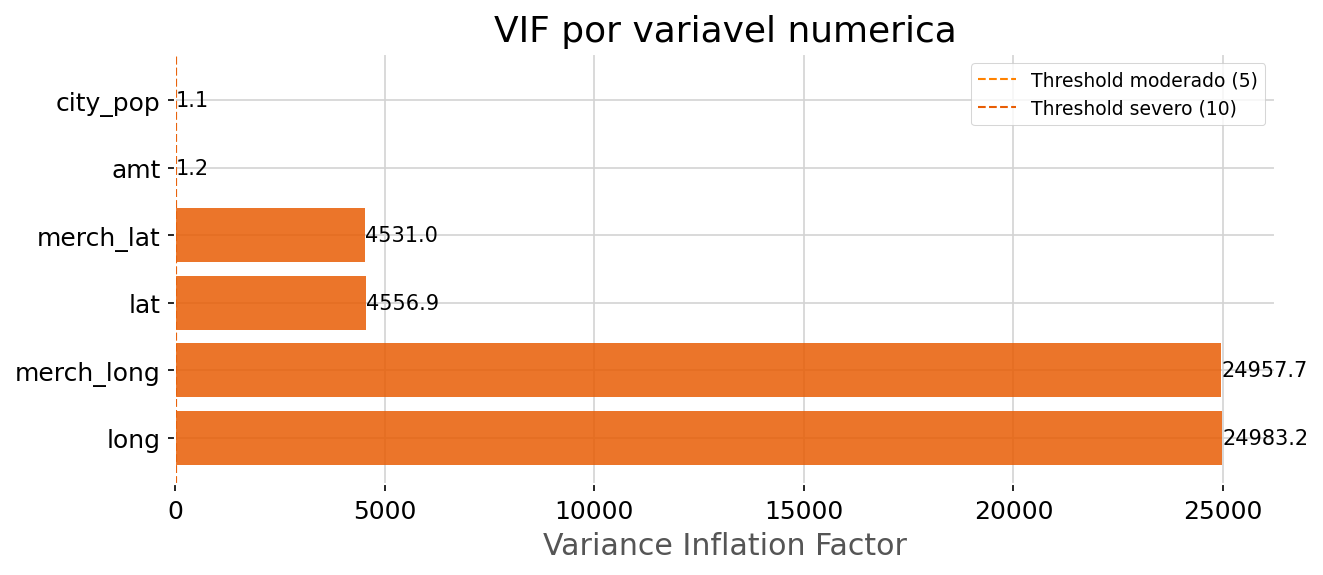

Resumo VIF:
  variavel      VIF
      long 24983.21
merch_long 24957.74
       lat  4556.93
 merch_lat  4530.97
       amt     1.19
  city_pop     1.10

Variaveis com multicolinearidade severa (VIF >= 10):
['long', 'merch_long', 'lat', 'merch_lat']
Essas variaveis serao candidatas a remocao ou substituicao por features compostas na secao 7.


In [13]:
# VIF calculado sobre as variaveis numericas antes do pre-processamento
numericas_vif = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']

df_vif = train[numericas_vif].dropna()

vif_resultado = pd.DataFrame({
    'variavel': numericas_vif,
    'VIF': [variance_inflation_factor(df_vif.values, i)
            for i in range(df_vif.shape[1])]
})
vif_resultado = vif_resultado.sort_values('VIF', ascending=False)

# visualizacao
fig, ax = plt.subplots(figsize=(9, 4))
cores_vif = ['#e85d04' if v >= 10 else '#ff8200' if v >= 5 else '#023047'
             for v in vif_resultado['VIF']]
bars = ax.barh(vif_resultado['variavel'], vif_resultado['VIF'],
               color=cores_vif, alpha=0.85)
ax.axvline(5,  color='#ff8200', linestyle='--', linewidth=1, label='Threshold moderado (5)')
ax.axvline(10, color='#e85d04', linestyle='--', linewidth=1, label='Threshold severo (10)')
ax.set_title('VIF por variavel numerica')
ax.set_xlabel('Variance Inflation Factor')
ax.legend(fontsize=9)
for bar, val in zip(bars, vif_resultado['VIF']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/05f_vif.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumo VIF:')
print(vif_resultado.to_string(index=False))
print()
severas = vif_resultado[vif_resultado['VIF'] >= 10]
if not severas.empty:
    print('Variaveis com multicolinearidade severa (VIF >= 10):')
    print(severas['variavel'].tolist())
    print('Essas variaveis serao candidatas a remocao ou substituicao por features compostas na secao 7.')

> **O que isso diz para o negócio**
>
> O VIF confirma de forma quantitativa o que a correlação sugeria: longitude e merch_long têm VIF acima de 24.000, latitude e merch_lat acima de 4.500. São níveis catastróficos de redundância. Já amt e city_pop têm VIF próximo de 1, totalmente independentes. Esse diagnóstico fundamenta a remoção das coordenadas brutas com argumento estatístico sólido, não apenas intuição.

## 2.9 Diagnóstico de Normalidade

Os histogramas dão leitura visual das distribuições, mas não respondem formalmente se uma variável é normal. Isso importa por dois motivos: justificar transformações e justificar a escolha do algoritmo. O Q-Q plot é a ferramenta visual padrão: pontos alinhados na diagonal indicam normalidade, desvios nas pontas indicam caudas pesadas. Como o teste de Shapiro-Wilk perde poder em amostras grandes, usamos o teste de D'Agostino-Pearson como complemento.

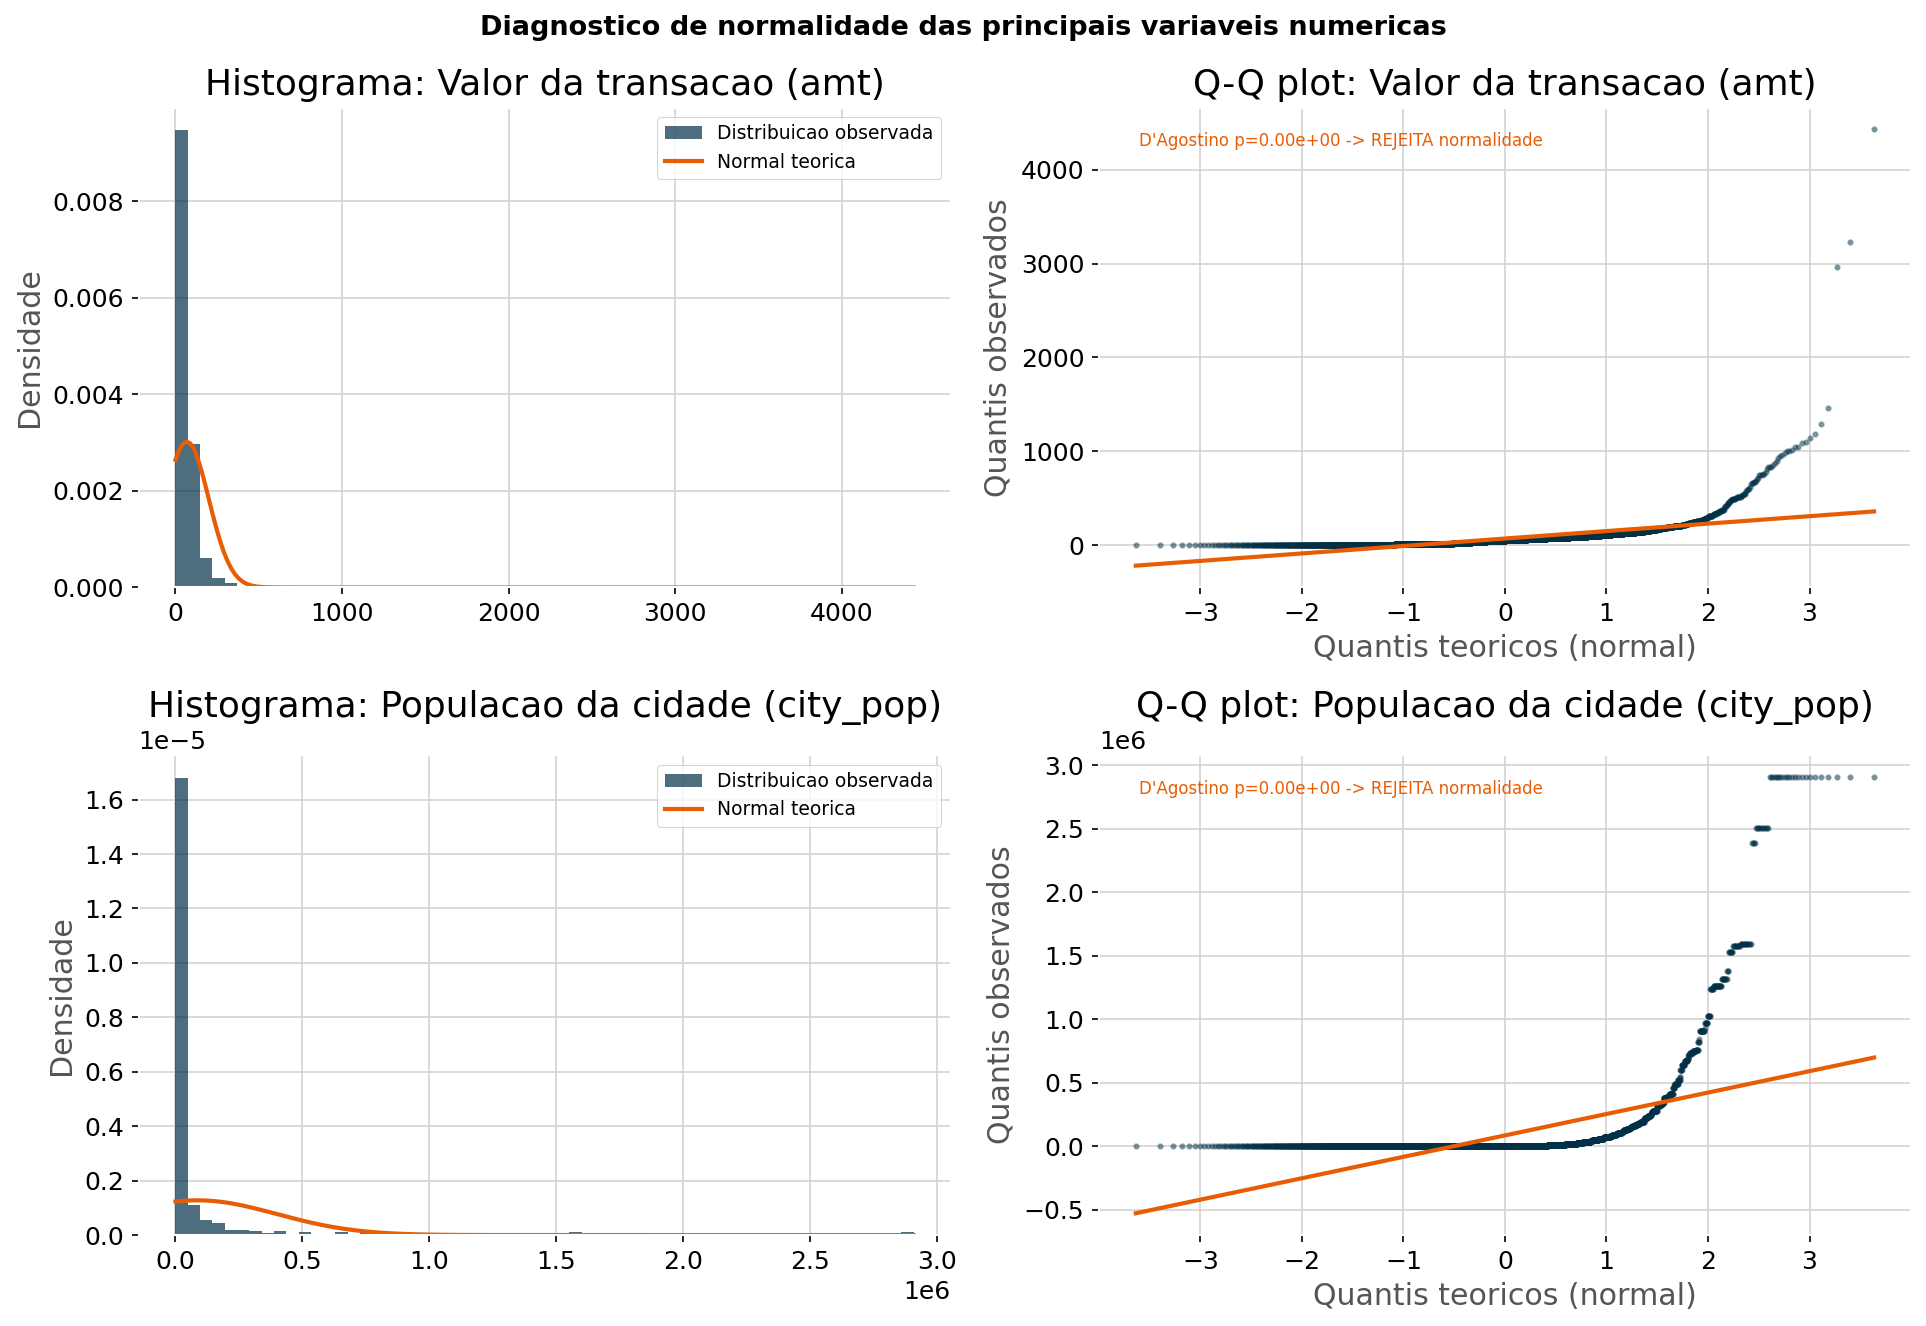

Conclusao: as distribuicoes de amt e city_pop sao fortemente assimetricas e nao normais.
Isso valida a escolha do XGBoost, que nao assume normalidade dos dados.
Em modelos lineares, essas variaveis exigiriam transformacao logaritmica antes de entrar.


In [14]:
# diagnostico de normalidade: Q-Q plots + teste D'Agostino-Pearson
variaveis_normalidade = [
    ('amt',      'Valor da transacao (amt)'),
    ('city_pop', 'Populacao da cidade (city_pop)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (col, label) in enumerate(variaveis_normalidade):
    amostra = train[col].dropna().sample(5000, random_state=RANDOM_STATE)

    # histograma com curva normal teorica sobreposta
    ax_hist = axes[row, 0]
    ax_hist.hist(amostra, bins=60, density=True,
                 color='#023047', alpha=0.7, label='Distribuicao observada')
    mu, sigma = amostra.mean(), amostra.std()
    x_norm = np.linspace(amostra.min(), amostra.max(), 200)
    ax_hist.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma),
                 color='#e85d04', linewidth=2, label='Normal teorica')
    ax_hist.set_title(f'Histograma: {label}')
    ax_hist.set_ylabel('Densidade')
    ax_hist.legend(fontsize=9)

    # Q-Q plot
    ax_qq = axes[row, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(amostra, dist='norm')
    ax_qq.plot(osm, osr, 'o', color='#023047', alpha=0.4, markersize=2)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='#e85d04', linewidth=2)
    ax_qq.set_title(f'Q-Q plot: {label}')
    ax_qq.set_xlabel('Quantis teoricos (normal)')
    ax_qq.set_ylabel('Quantis observados')

    # teste D'Agostino-Pearson
    stat, p = stats.normaltest(amostra)
    conclusao = 'REJEITA normalidade' if p < 0.05 else 'NAO rejeita normalidade'
    ax_qq.text(0.05, 0.92, f"D'Agostino p={p:.2e} -> {conclusao}",
               transform=ax_qq.transAxes, fontsize=8,
               color='#e85d04' if p < 0.05 else '#023047')

plt.suptitle('Diagnostico de normalidade das principais variaveis numericas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05g_normalidade.png', dpi=150, bbox_inches='tight')
plt.show()

print('Conclusao: as distribuicoes de amt e city_pop sao fortemente assimetricas e nao normais.')
print('Isso valida a escolha do XGBoost, que nao assume normalidade dos dados.')
print('Em modelos lineares, essas variaveis exigiriam transformacao logaritmica antes de entrar.')

> **O que isso diz para o negócio**
>
> Tanto amt quanto city_pop são fortemente assimétricas e não normais. Isso valida duas decisões técnicas: usar Spearman ao lado de Pearson na correlação, e escolher o XGBoost como algoritmo, já que árvores de decisão não assumem normalidade dos dados, ao contrário de modelos lineares.

## 2.10 Significância Estatística das Features (OLS Diagnóstico)

Existe uma pergunta que a exploração visual não responde: a relação entre cada variável e a fraude é estatisticamente real, ou pode ser ruído? O OLS (Mínimos Quadrados Ordinários) responde via teste t por coeficiente:

- **Hipótese nula (H0):** o coeficiente é zero, a variável não tem relação com a resposta.
- **Hipótese alternativa (H1):** o coeficiente é diferente de zero, a variável contribui.

O **p-valor** é a probabilidade de observar aquele coeficiente por acaso assumindo H0 verdadeira. Abaixo de 0.05, rejeitamos H0. Importante: o OLS aqui é ferramenta diagnóstica, não o modelo de predição.

                            OLS Regression Results                            
Dep. Variable:               is_fraud   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1020.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:11:37   Log-Likelihood:                -4870.0
No. Observations:               10000   AIC:                             9754.
Df Residuals:                    9993   BIC:                             9805.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2117      0.038      5.538      0.0

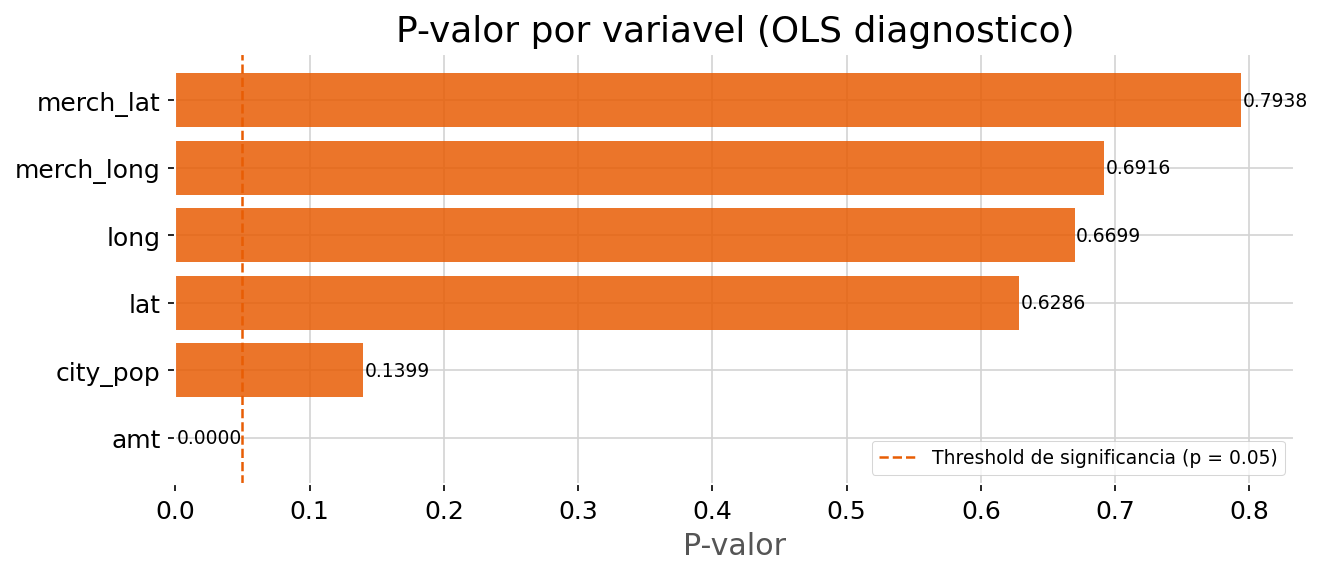

Variaveis estatisticamente significativas (p < 0.05): ['amt']
Variaveis sem significancia estatistica (p >= 0.05): ['city_pop', 'lat', 'long', 'merch_long', 'merch_lat']

Nota: variaveis nao significativas no OLS nao sao automaticamente descartadas.
O XGBoost captura relacoes nao lineares que o OLS nao detecta.
O diagnostico informa, nao decide.


In [15]:
# OLS diagnostico: significancia estatistica das features numericas
# usamos amostra estratificada para viabilizar o calculo sem perder representatividade
amostra_idx = train.groupby('is_fraud', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 5000), random_state=RANDOM_STATE)
).index
df_ols = train.loc[amostra_idx].copy()

features_ols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']

y_ols = df_ols['is_fraud']
X_ols = sm.add_constant(df_ols[features_ols].copy())

modelo_ols = sm.OLS(y_ols, X_ols).fit()
print(modelo_ols.summary())

# extraindo e visualizando p-valores
pvalores = modelo_ols.pvalues.drop('const').sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
cores_p = ['#023047' if p < 0.05 else '#e85d04' for p in pvalores.values]
ax.barh(pvalores.index, pvalores.values, color=cores_p, alpha=0.85)
ax.axvline(0.05, color='#e85d04', linestyle='--', linewidth=1.2,
           label='Threshold de significancia (p = 0.05)')
ax.set_title('P-valor por variavel (OLS diagnostico)')
ax.set_xlabel('P-valor')
ax.legend(fontsize=9)
for i, (var, val) in enumerate(pvalores.items()):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/05h_pvalores.png', dpi=150, bbox_inches='tight')
plt.show()

significativas = pvalores[pvalores < 0.05].index.tolist()
nao_significativas = pvalores[pvalores >= 0.05].index.tolist()
print(f'Variaveis estatisticamente significativas (p < 0.05): {significativas}')
print(f'Variaveis sem significancia estatistica (p >= 0.05): {nao_significativas}')
print()
print('Nota: variaveis nao significativas no OLS nao sao automaticamente descartadas.')
print('O XGBoost captura relacoes nao lineares que o OLS nao detecta.')
print('O diagnostico informa, nao decide.')

> **O que isso diz para o negócio**
>
> Apenas amt aparece com significância estatística absoluta (p < 0.001). As coordenadas geográficas têm p-valores altos (0.6 a 0.8), confirmando o VIF. E city_pop fica em 0.140, sem significância linear. Mas atenção: isso é significância linear. O XGBoost captura relações não lineares que o OLS não enxerga, então uma variável não significativa aqui não é automaticamente descartável, como veremos na modelagem.

## 2.11 Síntese dos Achados

Reunindo exploração visual e diagnóstico estatístico, o perfil das transações fraudulentas ficou claro:

- **Desbalanceamento severo:** 0,58% de fraudes exige tratamento de classe na modelagem.
- **Valor é o preditor mais forte:** confirmado por Pearson, Spearman e OLS. Fraudes têm valor médio 8x maior.
- **Padrão temporal claro:** concentração entre meia-noite e 4h, validando a feature de hora.
- **Categorias online de maior risco:** shopping_net e misc_net lideram as taxas.
- **Multicolinearidade nas coordenadas:** VIF e OLS confirmam redundância severa entre lat/long e merch_lat/merch_long. A informação útil está na distância, não nas coordenadas brutas.
- **Distribuições não normais:** amt e city_pop são assimétricas, validando Spearman e a escolha do XGBoost.

Esses achados guiam diretamente as decisões da próxima fase: quais colunas remover, quais features criar e qual estratégia de balanceamento adotar.

# 3. Preparação dos Dados

Com os achados da fase anterior, preparamos os dados para a modelagem. Cada decisão aqui tem respaldo direto nos diagnósticos: removemos o que o VIF e o OLS apontaram como redundante, criamos features que capturam os padrões que a exploração revelou, e cuidamos para não introduzir vazamento de dados.

## 3.1 Remoção de Colunas Irrelevantes e Redundantes

Removemos identificadores sem poder preditivo e as coordenadas geográficas brutas. A decisão sobre as coordenadas é fundamentada quantitativamente: o VIF da seção 2.8 mostrou colinearidade severa (acima de 24.000 para longitude) e o OLS da seção 2.10 confirmou ausência de significância individual. A informação geográfica útil será capturada pela feature de distância na próxima seção.

In [16]:
# remoção das colunas irrelevantes ou redundantes
colunas_remover = [
    'Unnamed: 0',            # índice duplicado
    'trans_date_trans_time', # extrairemos features de tempo separadamente
    'cc_num',               # identificador único do cartão
    'first', 'last',        # nome do titular   não preditivo
    'street',               # endereço específico   muito granular
    'trans_num',            # ID único da transação
    'unix_time',            # redundante com trans_date_trans_time
    'dob',                  # data bruta   criaremos a feature 'idade'
    'faixa_valor'           # coluna auxiliar criada no EDA
]

train_clean = train.drop(columns=colunas_remover)
test_clean  = test.drop(columns=colunas_remover, errors='ignore')

print('Colunas restantes:', train_clean.columns.tolist())


Colunas restantes: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud']


> **O que isso diz para o negócio**
>
> Enxugar o conjunto de variáveis não é perda de informação, é remoção de ruído. Um modelo mais enxuto é mais rápido de treinar, mais fácil de manter em produção e menos propenso a instabilidade. Cada coluna removida foi justificada por evidência estatística.

## 3.2 Feature Engineering

Criamos variáveis que capturam os padrões identificados na exploração: a distância entre titular e estabelecimento (substituindo as coordenadas brutas), a hora do dia e o dia da semana (capturando o padrão temporal de madrugada), e a idade do titular a partir da data de nascimento.

In [17]:
# idade do titular
train_clean['idade'] = 2024 - pd.to_datetime(train['dob']).dt.year
test_clean['idade']  = 2024 - pd.to_datetime(test['dob']).dt.year

# hora da transação
train_clean['hora'] = pd.to_datetime(train['trans_date_trans_time']).dt.hour
test_clean['hora']  = pd.to_datetime(test['trans_date_trans_time']).dt.hour

# dia da semana
train_clean['dia_semana'] = pd.to_datetime(train['trans_date_trans_time']).dt.dayofweek
test_clean['dia_semana']  = pd.to_datetime(test['trans_date_trans_time']).dt.dayofweek

# distância geográfica entre cliente e estabelecimento
train_clean['distancia'] = np.sqrt(
    (train_clean['lat'] - train_clean['merch_lat'])**2 +
    (train_clean['long'] - train_clean['merch_long'])**2
)
test_clean['distancia'] = np.sqrt(
    (test_clean['lat'] - test_clean['merch_lat'])**2 +
    (test_clean['long'] - test_clean['merch_long'])**2
)

print('Features criadas com sucesso!')
print(train_clean[['idade', 'hora', 'dia_semana', 'distancia']].describe())


Features criadas com sucesso!
           idade       hora  dia_semana  distancia
count 1296675.00 1296675.00  1296675.00 1296675.00
mean       50.74      12.80        3.07       0.77
std        17.38       6.82        2.20       0.28
min        19.00       0.00        0.00       0.00
25%        37.00       7.00        1.00       0.56
50%        49.00      14.00        3.00       0.80
75%        62.00      19.00        5.00       0.98
max       100.00      23.00        6.00       1.41


> **O que isso diz para o negócio**
>
> A feature de distância transforma quatro coordenadas redundantes em um único sinal interpretável: o quão longe a compra aconteceu do endereço do titular. Compras muito distantes são naturalmente mais suspeitas. As features de tempo permitem ao modelo aprender o padrão de madrugada que vimos na exploração.

## 3.3 Encoding das Variáveis Categóricas

Convertemos variáveis categóricas em numéricas com Label Encoding, com um cuidado fundamental: o encoder é treinado (`fit`) exclusivamente nos dados de treino e apenas aplicado (`transform`) no teste.

Fazer `fit_transform` separado em treino e teste seria **data leakage**: o encoder aprenderia a distribuição do conjunto de teste, o que em produção é impossível, pois os dados futuros não existem no momento do treino. Esse erro produziria resultados artificialmente otimistas que não se sustentam na vida real.

In [18]:
# encoding correto: fit apenas no treino, transform em treino e teste
categoricas = ['merchant', 'category', 'gender', 'city', 'state', 'job']

encoders = {}
for col in categoricas:
    le = LabelEncoder()
    train_clean[col] = le.fit_transform(train_clean[col].astype(str))
    encoders[col] = le

    # aplica o mesmo encoder ao teste
    # categorias desconhecidas no teste recebem -1
    test_clean[col] = test_clean[col].astype(str).map(
        lambda x, enc=le: enc.transform([x])[0]
        if x in enc.classes_ else -1
    )

print('Encoding concluido sem data leakage.')
print(f'Encoders salvos para {len(encoders)} colunas.')

Encoding concluido sem data leakage.
Encoders salvos para 6 colunas.


> **O que isso diz para o negócio**
>
> Prevenir vazamento de dados é o que separa um modelo que funciona no notebook de um que funciona em produção. Garantir que o pré-processamento do teste use apenas o conhecimento do treino é a forma de ter confiança de que as métricas reportadas vão se repetir quando o modelo encontrar transações de verdade.

## 3.4 Separação de Features e Variável Alvo

Definição final das matrizes de features (X) e do vetor alvo (y) para treino e teste.

In [19]:
# definindo X e y para treino e teste
features_remover = ['is_fraud', 'lat', 'long', 'merch_lat', 'merch_long', 'zip']

X_train = train_clean.drop(columns=features_remover)
y_train = train_clean['is_fraud']

X_test  = test_clean.drop(columns=features_remover, errors='ignore')
y_test  = test_clean['is_fraud'] if 'is_fraud' in test_clean.columns else None

print('Shape X_train:', X_train.shape)
print('Shape X_test :', X_test.shape)
print('\nFeatures utilizadas:')
print(X_train.columns.tolist())
print('\nDistribuição y_train:')
print(y_train.value_counts())


Shape X_train: (1296675, 12)
Shape X_test : (555719, 12)

Features utilizadas:
['merchant', 'category', 'amt', 'gender', 'city', 'state', 'city_pop', 'job', 'idade', 'hora', 'dia_semana', 'distancia']

Distribuição y_train:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


# 4. Modelagem

Esta fase testa diferentes abordagens para construir o melhor classificador possível. Começamos definindo a estratégia de balanceamento, treinamos um baseline, comparamos algoritmos, validamos a estabilidade, otimizamos hiperparâmetros, interpretamos o modelo com SHAP e por fim testamos hipóteses de refinamento nascidas dos diagnósticos estatísticos.

## 4.0 Função de Avaliação de Impacto Financeiro

Antes de treinar os modelos, definimos a função que traduz as predições em impacto financeiro: valor das fraudes evitadas menos o custo das legítimas bloqueadas. Essa função é usada para comparar todos os modelos sob a ótica do negócio, não apenas das métricas estatísticas.

In [20]:
# função de cálculo de impacto financeiro
def calcular_impacto(y_real, y_pred, valores):
    tp = ((y_real == 1) & (y_pred == 1))
    fn = ((y_real == 1) & (y_pred == 0))
    fp = ((y_real == 0) & (y_pred == 1))
    evitadas   = valores[tp].sum()
    perdidas   = valores[fn].sum()
    bloqueadas = valores[fp].sum()
    return {
        'n_alertas'  : int(y_pred.sum()),
        'n_tp'       : int(tp.sum()),
        'n_fp'       : int(fp.sum()),
        'evitadas'   : evitadas,
        'perdidas'   : perdidas,
        'bloqueadas' : bloqueadas,
        'saldo'      : evitadas - bloqueadas,
    }

valores_test = X_test['amt'].values
y_real       = y_test.values

print('Funcao de impacto financeiro definida.')

Funcao de impacto financeiro definida.


## 4.1 Estratégia de Balanceamento

O desbalanceamento de 0,58% identificado na fase 2 exige tratamento. Testamos duas abordagens: SMOTE combinado com undersampling, que reequilibra as classes sinteticamente, e o parâmetro scale_pos_weight do XGBoost, que penaliza erros na classe minoritária sem alterar os dados.

In [21]:
# análise da distribuição antes do balanceamento
print('Distribuição antes do balanceamento:')
print(Counter(y_train))
print(f'Razão: 1 fraude para cada {Counter(y_train)[0] // Counter(y_train)[1]} legítimas')

# configuração do pipeline SMOTE
under = RandomUnderSampler(sampling_strategy=0.1, random_state=RANDOM_STATE)
over  = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)

# balanceamento combinado
pipeline_bal = Pipeline([('under', under), ('over', over)])
X_bal, y_bal = pipeline_bal.fit_resample(X_train, y_train)

total_bal = len(y_bal)
print('\nDistribuição após SMOTE + Undersampling:')
print(Counter(y_bal))
print(f"Legítimas : {Counter(y_bal)[0]:,} ({Counter(y_bal)[0]/total_bal*100:.1f}%)")
print(f"Fraudes   : {Counter(y_bal)[1]:,} ({Counter(y_bal)[1]/total_bal*100:.1f}%)")


Distribuição antes do balanceamento:
Counter({0: 1289169, 1: 7506})
Razão: 1 fraude para cada 171 legítimas

Distribuição após SMOTE + Undersampling:
Counter({0: 75060, 1: 37530})
Legítimas : 75,060 (66.7%)
Fraudes   : 37,530 (33.3%)


### 4.1.1 Estratégia SMOTE + Undersampling

O SMOTE cria exemplos sintéticos da classe minoritária interpolando vizinhos próximos, enquanto o undersampling reduz a classe majoritária. O objetivo é equilibrar sem perder informação demais.

In [22]:
# calculando a razão de desbalanceamento
ratio = Counter(y_train)[0] / Counter(y_train)[1]
print(f'Razão de desbalanceamento: {ratio:.1f}')
print(f'scale_pos_weight que será usado: {ratio:.1f}')
print('\nO modelo treinará diretamente nos dados originais sem resampling.')


Razão de desbalanceamento: 171.8
scale_pos_weight que será usado: 171.8

O modelo treinará diretamente nos dados originais sem resampling.


### 4.1.2 Estratégia scale_pos_weight

Em vez de alterar os dados, o scale_pos_weight ajusta o peso dos erros durante o treino, fazendo o modelo dar mais importância à classe de fraude. Mantém os dados originais intactos.

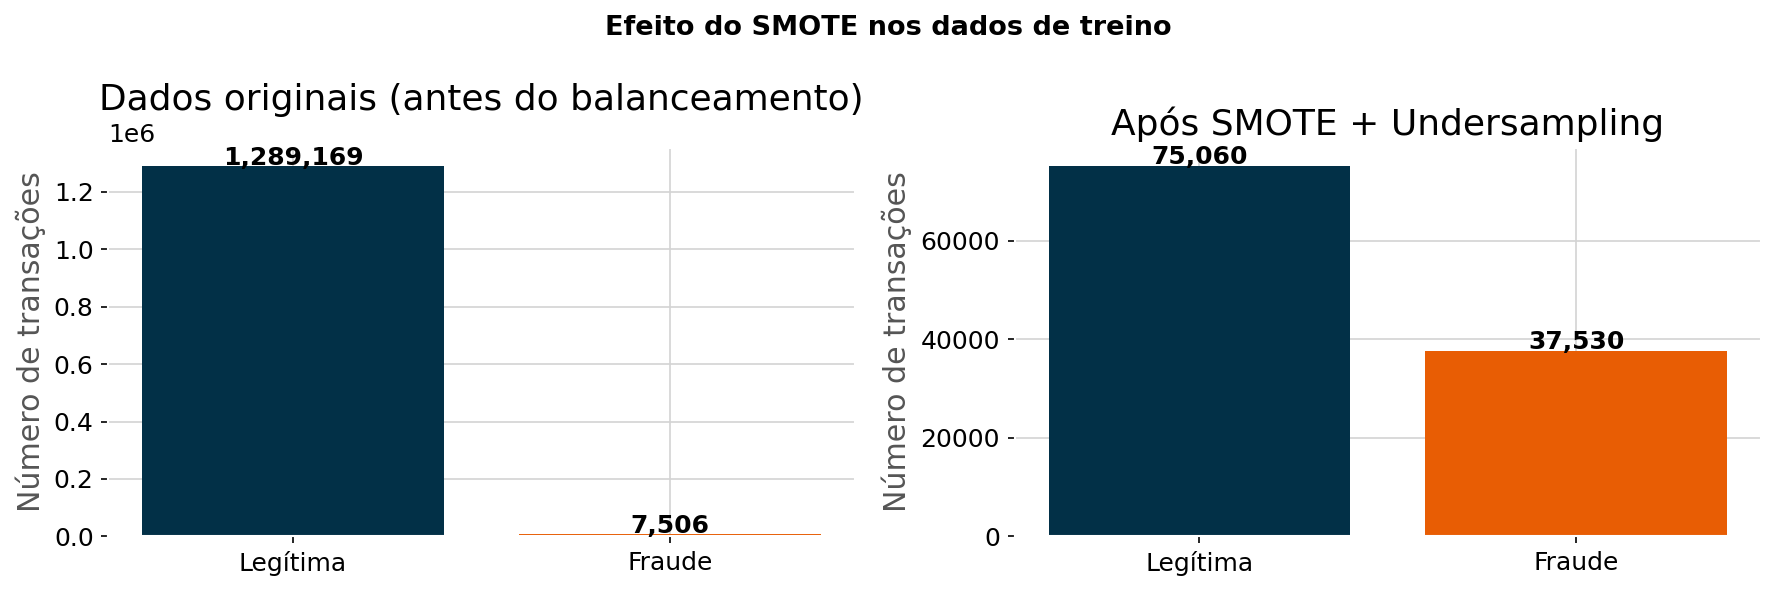

In [23]:
# visualização do impacto do SMOTE para referência
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legítima', 'Fraude'],
            [Counter(y_train)[0], Counter(y_train)[1]],
            color=['#023047', '#e85d04'])
axes[0].set_title('Dados originais (antes do balanceamento)')
axes[0].set_ylabel('Número de transações')
for i, v in enumerate([Counter(y_train)[0], Counter(y_train)[1]]):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(['Legítima', 'Fraude'],
            [Counter(y_bal)[0], Counter(y_bal)[1]],
            color=['#023047', '#e85d04'])
axes[1].set_title('Após SMOTE + Undersampling')
axes[1].set_ylabel('Número de transações')
for i, v in enumerate([Counter(y_bal)[0], Counter(y_bal)[1]]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Efeito do SMOTE nos dados de treino', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05_balanceamento.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> As duas estratégias atacam o mesmo problema por caminhos diferentes. O scale_pos_weight tende a ser preferível em produção por não criar dados sintéticos, mantendo o modelo mais fiel à realidade. A comparação na modelagem vai confirmar qual entrega melhor resultado.

## 4.2 Modelo Baseline: Árvore de Decisão

Toda modelagem séria começa com um baseline simples. A árvore de decisão única serve de referência: qualquer modelo mais complexo precisa superá-la para justificar sua complexidade.

In [24]:
# configuração e treino da Árvore de Decisão nos dados balanceados
print('Treinando Árvore de Decisão...')
inicio = time.time()

arvore = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)
arvore.fit(X_bal, y_bal)
print(f'Tempo de treino: {time.time() - inicio:.1f}s')

y_pred_arvore = arvore.predict(X_test)
y_prob_arvore = arvore.predict_proba(X_test)[:, 1]

print('\nÁRVORE DE DECISÃO')
print(classification_report(y_test, y_pred_arvore, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_arvore):.4f}')


Treinando Árvore de Decisão...
Tempo de treino: 0.8s

ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99    553574
      Fraude       0.16      0.93      0.27      2145

    accuracy                           0.98    555719
   macro avg       0.58      0.96      0.63    555719
weighted avg       1.00      0.98      0.99    555719

AUC-ROC: 0.9842


> **O que isso diz para o negócio**
>
> O baseline estabelece o piso de desempenho. Ele já captura padrões básicos, mas árvores únicas tendem a overfitting e instabilidade. É o ponto de partida que os modelos de ensemble vão superar.

## 4.3 XGBoost: SMOTE vs scale_pos_weight

O XGBoost é um ensemble de árvores com regularização, robusto a multicolinearidade e a distribuições não normais, exatamente o perfil dos nossos dados. Treinamos duas versões, uma com cada estratégia de balanceamento.

In [25]:
# configuração e treino do XGBoost nos dados balanceados com SMOTE
print('Treinando XGBoost (SMOTE)...')
inicio = time.time()

xgb_smote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_smote.fit(X_bal, y_bal)
print(f'Tempo de treino: {time.time() - inicio:.1f}s')

y_pred_smote = xgb_smote.predict(X_test)
y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]

print('\nXGBOOST   SMOTE')
print(classification_report(y_test, y_pred_smote, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_smote):.4f}')


Treinando XGBoost (SMOTE)...
Tempo de treino: 4.9s

XGBOOST   SMOTE
              precision    recall  f1-score   support

    Legítima       1.00      0.99      0.99    553574
      Fraude       0.24      0.89      0.38      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.94      0.69    555719
weighted avg       1.00      0.99      0.99    555719

AUC-ROC: 0.9894


In [26]:
# configuração e treino do XGBoost nos dados originais com scale_pos_weight
print('Treinando XGBoost (scale_pos_weight)...')
inicio = time.time()

xgb_spw = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_spw.fit(X_train, y_train)
print(f'Tempo de treino: {time.time() - inicio:.1f}s')

y_pred_spw = xgb_spw.predict(X_test)
y_prob_spw = xgb_spw.predict_proba(X_test)[:, 1]

print('\nXGBOOST   scale_pos_weight')
print(classification_report(y_test, y_pred_spw, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_spw):.4f}')


Treinando XGBoost (scale_pos_weight)...
Tempo de treino: 20.3s

XGBOOST   scale_pos_weight
              precision    recall  f1-score   support

    Legítima       1.00      0.99      1.00    553574
      Fraude       0.28      0.94      0.44      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.97      0.72    555719
weighted avg       1.00      0.99      0.99    555719

AUC-ROC: 0.9970


> **O que isso diz para o negócio**
>
> O XGBoost supera o baseline com folga em ambas as estratégias. A versão com scale_pos_weight entrega o melhor equilíbrio entre capturar fraudes e não bloquear legítimas, além de ser mais simples de operar em produção por não depender de geração de dados sintéticos.

## 4.4 Comparação Visual dos Modelos

Consolidamos o desempenho dos três modelos (baseline, XGBoost SMOTE, XGBoost scale_pos_weight) em tabela, gráficos comparativos, curva ROC e matrizes de confusão.

In [27]:
# tabela comparativa calculada dinamicamente
resultados = pd.DataFrame({
    'Modelo'             : ['Árvore de Decisão', 'XGBoost SMOTE', 'XGBoost scale_pos_weight'],
    'Precision (Fraude)' : [round(precision_score(y_test, y_pred_arvore), 2),
                            round(precision_score(y_test, y_pred_smote), 2),
                            round(precision_score(y_test, y_pred_spw), 2)],
    'Recall (Fraude)'    : [round(recall_score(y_test, y_pred_arvore), 2),
                            round(recall_score(y_test, y_pred_smote), 2),
                            round(recall_score(y_test, y_pred_spw), 2)],
    'F1 (Fraude)'        : [round(f1_score(y_test, y_pred_arvore), 2),
                            round(f1_score(y_test, y_pred_smote), 2),
                            round(f1_score(y_test, y_pred_spw), 2)],
    'AUC-ROC'            : [round(roc_auc_score(y_test, y_prob_arvore), 4),
                            round(roc_auc_score(y_test, y_prob_smote), 4),
                            round(roc_auc_score(y_test, y_prob_spw), 4)],
})
print(resultados.to_string(index=False))


                  Modelo  Precision (Fraude)  Recall (Fraude)  F1 (Fraude)  AUC-ROC
       Árvore de Decisão                0.16             0.93         0.27     0.98
           XGBoost SMOTE                0.24             0.89         0.38     0.99
XGBoost scale_pos_weight                0.28             0.94         0.44     1.00


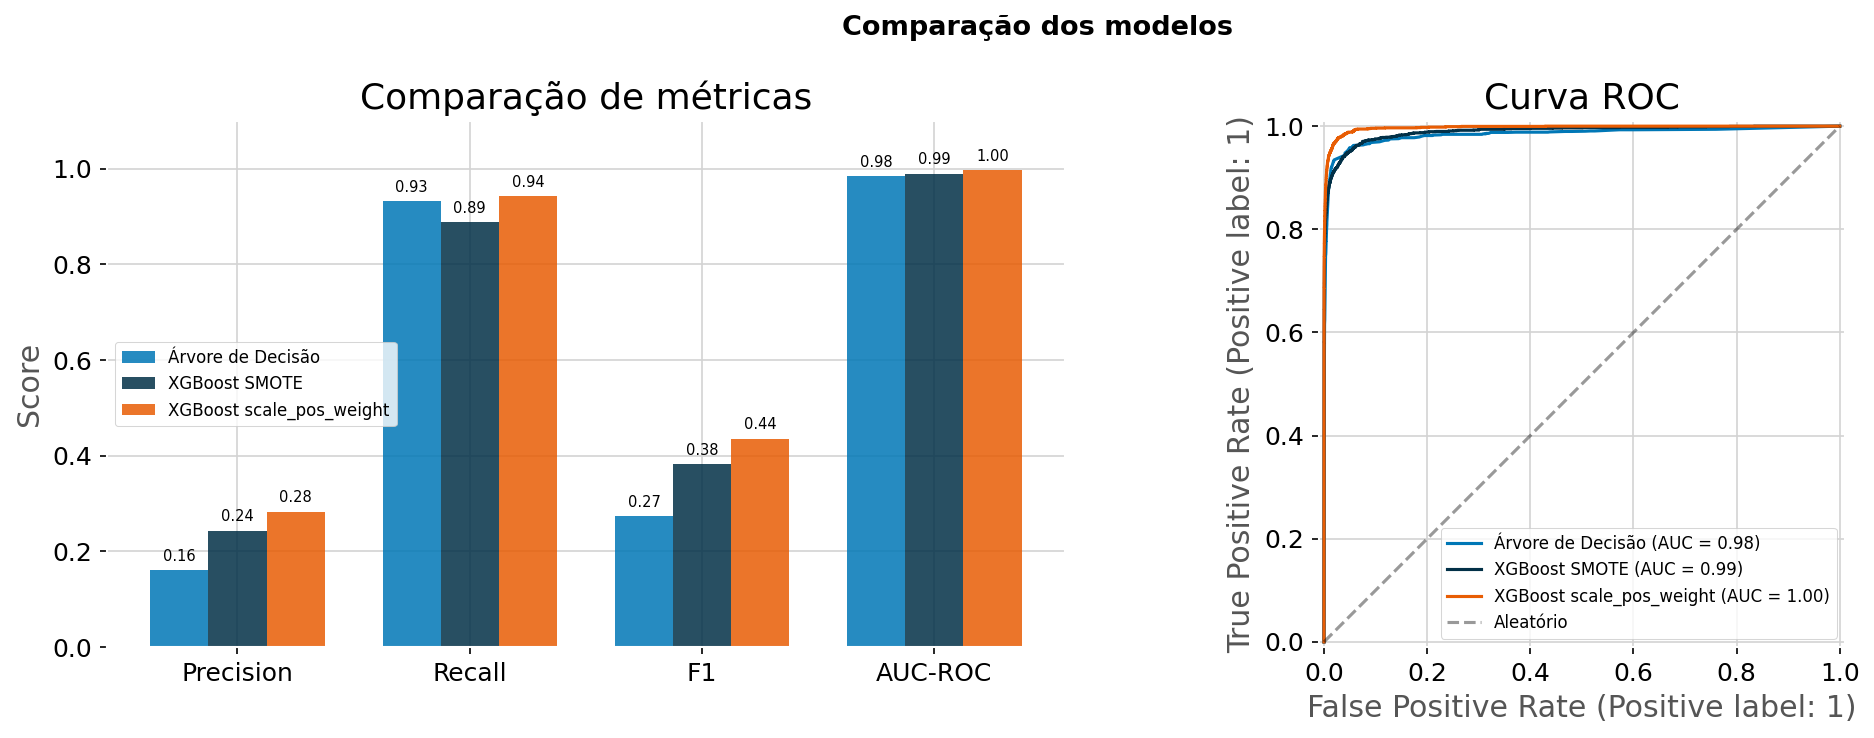

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_metricas = ['Precision', 'Recall', 'F1', 'AUC-ROC']
vals_arvore = [precision_score(y_test, y_pred_arvore), recall_score(y_test, y_pred_arvore),
               f1_score(y_test, y_pred_arvore), roc_auc_score(y_test, y_prob_arvore)]
vals_smote  = [precision_score(y_test, y_pred_smote), recall_score(y_test, y_pred_smote),
               f1_score(y_test, y_pred_smote), roc_auc_score(y_test, y_prob_smote)]
vals_spw    = [precision_score(y_test, y_pred_spw), recall_score(y_test, y_pred_spw),
               f1_score(y_test, y_pred_spw), roc_auc_score(y_test, y_prob_spw)]

x     = np.arange(len(labels_metricas))
width = 0.25

axes[0].bar(x - width, vals_arvore, width, label='Árvore de Decisão',       color='#0077b6', alpha=0.85)
axes[0].bar(x,         vals_smote,  width, label='XGBoost SMOTE',            color='#023047', alpha=0.85)
axes[0].bar(x + width, vals_spw,    width, label='XGBoost scale_pos_weight', color='#e85d04', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_metricas)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Comparação de métricas')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
for i, (a, b, c) in enumerate(zip(vals_arvore, vals_smote, vals_spw)):
    axes[0].text(i - width, a + 0.02, f'{a:.2f}', ha='center', fontsize=7)
    axes[0].text(i,         b + 0.02, f'{b:.2f}', ha='center', fontsize=7)
    axes[0].text(i + width, c + 0.02, f'{c:.2f}', ha='center', fontsize=7)

# curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob_arvore, name='Árvore de Decisão',       ax=axes[1], color='#0077b6')
RocCurveDisplay.from_predictions(y_test, y_prob_smote,  name='XGBoost SMOTE',            ax=axes[1], color='#023047')
RocCurveDisplay.from_predictions(y_test, y_prob_spw,    name='XGBoost scale_pos_weight', ax=axes[1], color='#e85d04')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatório')
axes[1].set_title('Curva ROC')
axes[1].legend(fontsize=8)

plt.suptitle('Comparação dos modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/06_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> A curva ROC mostra os três modelos com AUC alto, mas o XGBoost com scale_pos_weight se destaca no equilíbrio geral. Para o negócio, a leitura é direta: temos um modelo confiável de separar fraude de transação legítima.

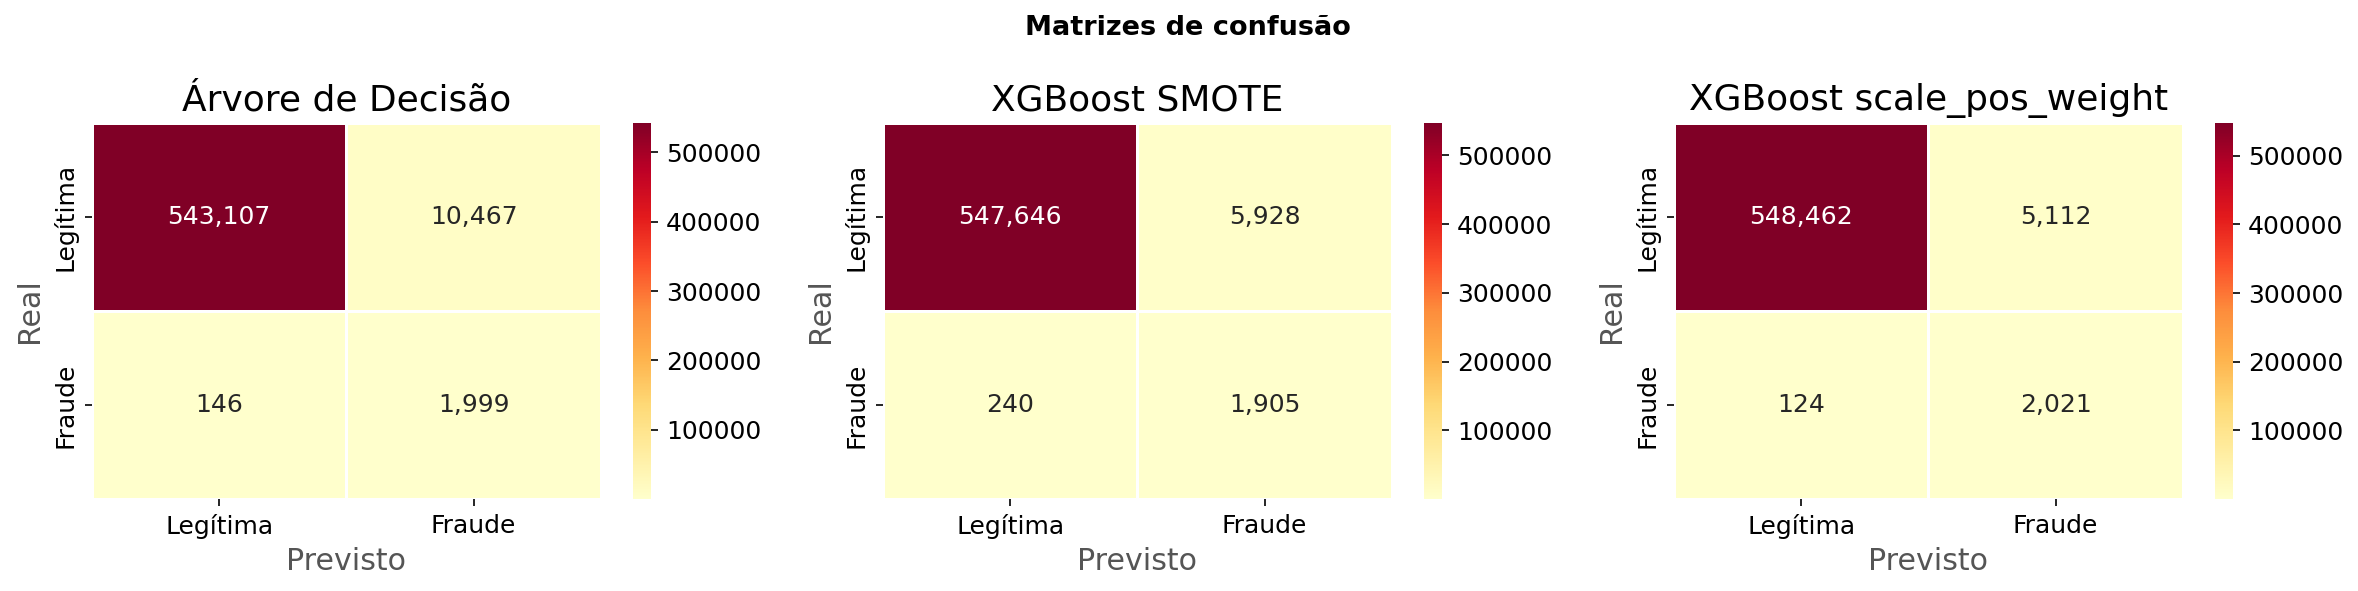

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_pred, titulo in zip(axes,
    [y_pred_arvore, y_pred_smote, y_pred_spw],
    ['Árvore de Decisão', 'XGBoost SMOTE', 'XGBoost scale_pos_weight']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='YlOrRd', ax=ax,
                xticklabels=['Legítima', 'Fraude'],
                yticklabels=['Legítima', 'Fraude'],
                linewidths=0.5)
    ax.set_title(titulo)
    ax.set_ylabel('Real')
    ax.set_xlabel('Previsto')

plt.suptitle('Matrizes de confusão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/07_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> As matrizes de confusão traduzem o desempenho em números concretos de acertos e erros. O que importa para o negócio é o canto dos falsos negativos (fraudes que passaram) e dos falsos positivos (legítimas bloqueadas). O modelo escolhido minimiza o primeiro sem explodir o segundo.

## 4.5 Importância das Features (XGBoost)

A importância nativa do XGBoost mostra quais variáveis o modelo mais usou para tomar decisões de split. É uma primeira leitura global, que será aprofundada com SHAP mais adiante.

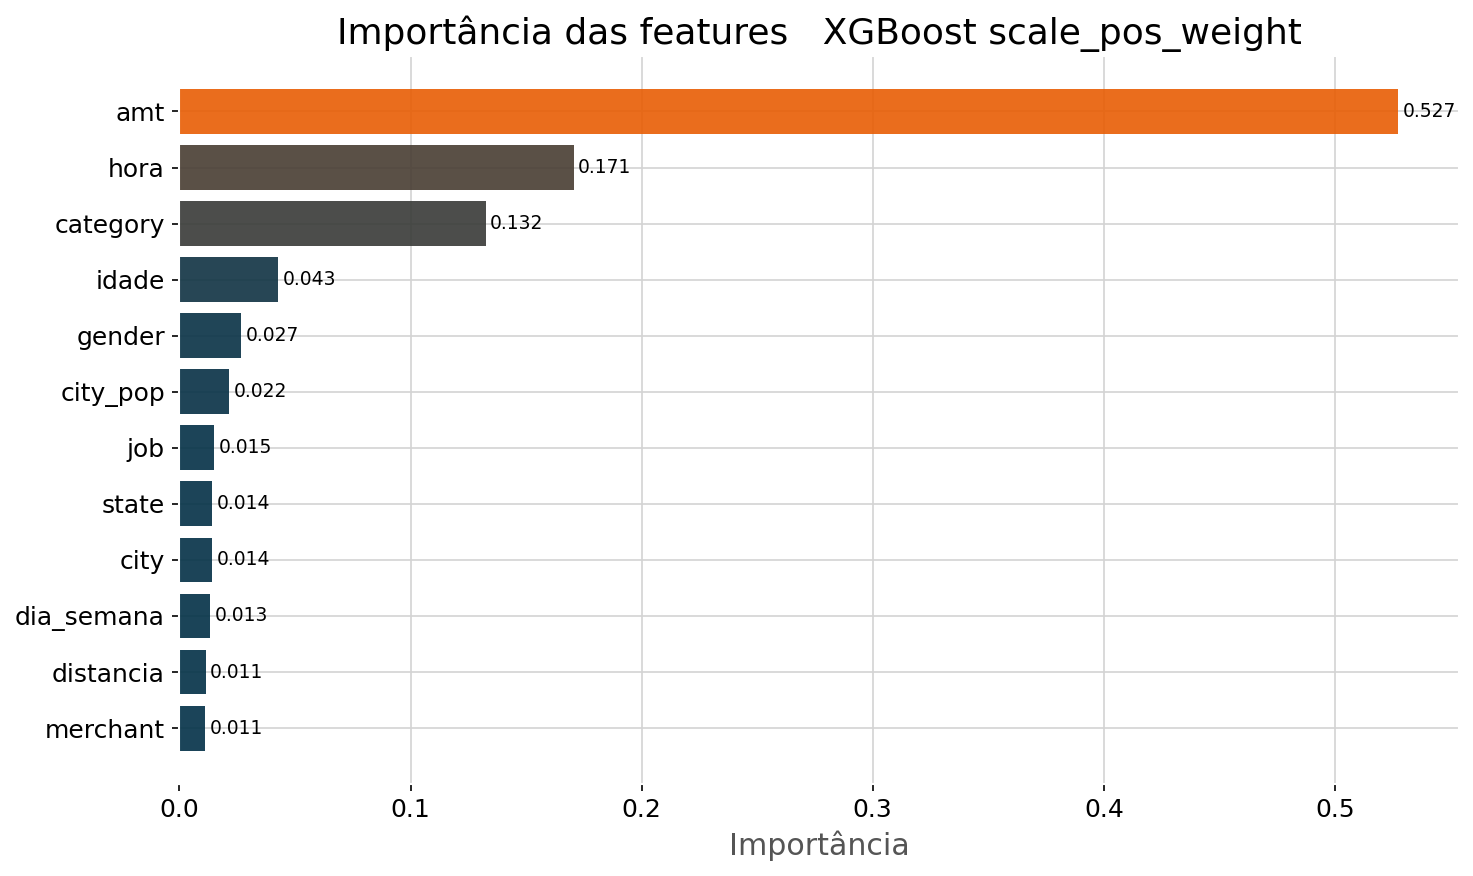

In [30]:
# análise da importância das features no modelo principal
feat_imp = pd.Series(xgb_spw.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True)

# gradiente de cores pela importância
norm = (feat_imp.values - feat_imp.values.min()) / (feat_imp.values.max() - feat_imp.values.min())
cores_imp = []
for n in norm:
    r = int(0x02 + n * (0xe8 - 0x02))
    g = int(0x30 + n * (0x5d - 0x30))
    b = int(0x47 + n * (0x04 - 0x47))
    cores_imp.append(f'#{r:02x}{g:02x}{b:02x}')

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp.index, feat_imp.values, color=cores_imp, alpha=0.9)
plt.title('Importância das features   XGBoost scale_pos_weight')
plt.xlabel('Importância')
for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> O valor da transação domina a importância, confirmando todos os achados estatísticos da fase 2. As features de tempo e categoria também aparecem com peso relevante, validando o feature engineering. O modelo está usando exatamente os sinais que a análise de negócio indicou como importantes.

## 4.6 Cross-Validation

Uma única divisão treino/teste pode dar resultado enganoso por sorte na separação. A validação cruzada estratificada testa o modelo em múltiplas divisões diferentes, medindo se o desempenho é estável e confiável.

CROSS-VALIDATION   XGBoost scale_pos_weight (5 folds)
f1          : 0.5603 (+/- 0.0066)
roc_auc     : 0.9981 (+/- 0.0005)
precision   : 0.3956 (+/- 0.0064)
recall      : 0.9602 (+/- 0.0029)


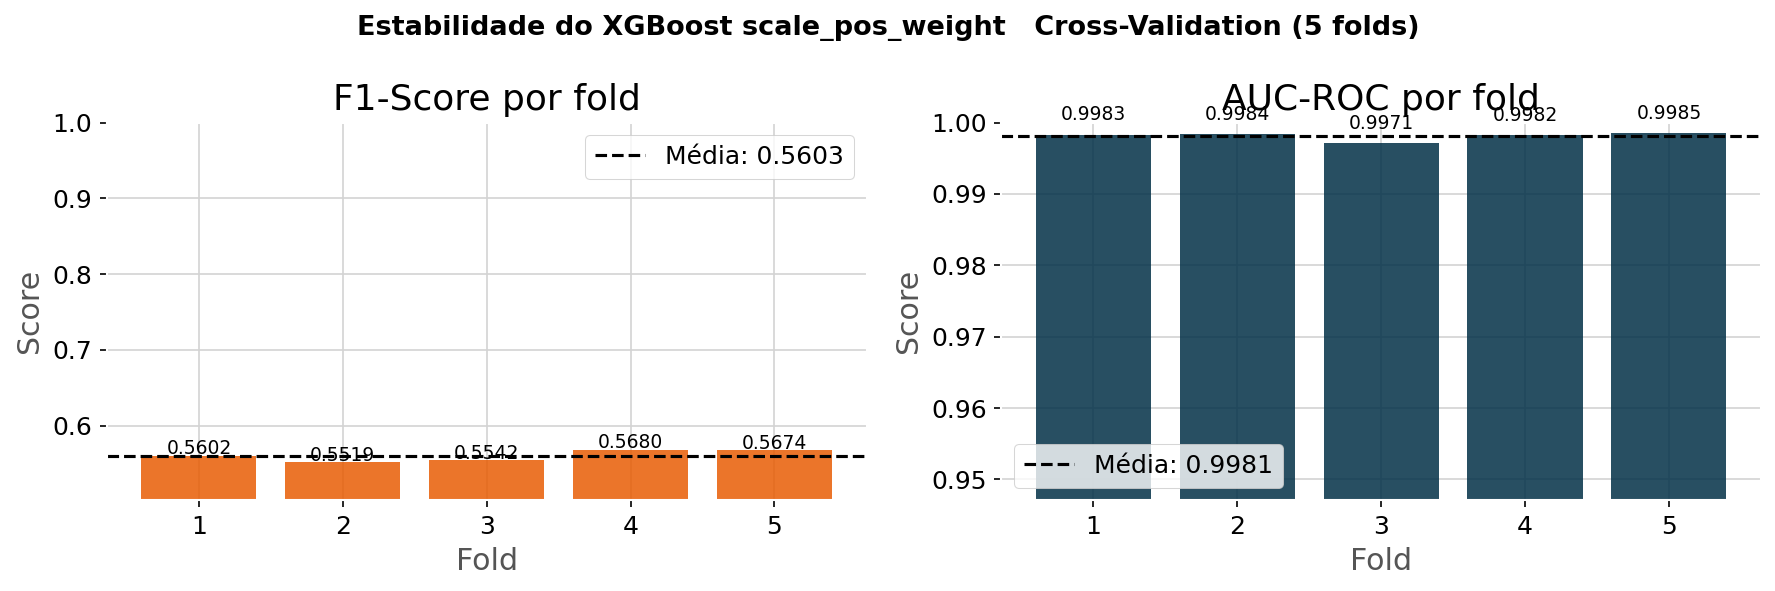

In [31]:
# cross-validation do modelo principal (scale_pos_weight)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_spw = cross_validate(
    xgb_spw, X_train, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    n_jobs=-1
)

print('CROSS-VALIDATION   XGBoost scale_pos_weight (5 folds)')
for metrica in ['f1', 'roc_auc', 'precision', 'recall']:
    vals = scores_spw[f'test_{metrica}']
    print(f'{metrica:12}: {vals.mean():.4f} (+/- {vals.std():.4f})')

# gráfico de estabilidade por fold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metrica, titulo, cor in zip(
    axes,
    ['f1', 'roc_auc'],
    ['F1-Score por fold', 'AUC-ROC por fold'],
    ['#e85d04', '#023047']
):
    vals = scores_spw[f'test_{metrica}']
    ax.bar(range(1, 6), vals, color=cor, alpha=0.85)
    ax.axhline(vals.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Média: {vals.mean():.4f}')
    ax.set_title(titulo)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_ylim(vals.min() - 0.05, 1.0)
    ax.legend()
    for i, v in enumerate(vals):
        ax.text(i+1, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Estabilidade do XGBoost scale_pos_weight   Cross-Validation (5 folds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/11_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> A estabilidade entre os folds dá confiança de que o desempenho não foi sorte de uma divisão específica. Para o negócio, isso significa que as métricas reportadas são confiáveis e devem se repetir em produção.

## 4.7 Otimização de Hiperparâmetros

Com o algoritmo definido, buscamos a melhor combinação de hiperparâmetros via RandomizedSearchCV, que testa combinações aleatórias do espaço de busca de forma mais eficiente que a busca exaustiva.

In [32]:
# espaço de busca dos hiperparâmetros
param_dist = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma'           : [0, 0.1, 0.2, 0.3, 0.5],
}

# scoring=f1, n_iter=20, cv=3 para equilibrar qualidade e tempo
busca_spw = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=ratio,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('Iniciando busca de hiperparâmetros...')
inicio = time.time()
busca_spw.fit(X_train, y_train)
print(f'\nBusca concluída em {(time.time()-inicio)/60:.1f} minutos')
print('\nMelhores hiperparâmetros encontrados:')
for param, valor in busca_spw.best_params_.items():
    print(f'  {param:20}: {valor}')
print(f'\nMelhor F1 no cross-validation: {busca_spw.best_score_:.4f}')


Iniciando busca de hiperparâmetros...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Busca concluída em 9.4 minutos

Melhores hiperparâmetros encontrados:
  subsample           : 0.8
  n_estimators        : 200
  min_child_weight    : 3
  max_depth           : 8
  learning_rate       : 0.3
  gamma               : 0.3
  colsample_bytree    : 1.0

Melhor F1 no cross-validation: 0.8181


In [33]:
# avaliação do modelo otimizado
xgb_spw_otim    = busca_spw.best_estimator_
y_pred_spw_otim = xgb_spw_otim.predict(X_test)
y_prob_spw_otim = xgb_spw_otim.predict_proba(X_test)[:, 1]

print('XGBOOST scale_pos_weight OTIMIZADO')
print(classification_report(y_test, y_pred_spw_otim, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_spw_otim):.4f}')

# comparação original vs otimizado
print('\n' + '=' * 55)
print(f'{"Métrica":25} {"Original":>12} {"Otimizado":>12}')
print('=' * 55)
metricas_comp = {
    'Precision (Fraude)': (precision_score, y_pred_spw, y_pred_spw_otim),
    'Recall (Fraude)'   : (recall_score,    y_pred_spw, y_pred_spw_otim),
    'F1-Score (Fraude)' : (f1_score,        y_pred_spw, y_pred_spw_otim),
}
for nome, (func, pred_orig, pred_otim) in metricas_comp.items():
    v_orig = func(y_test, pred_orig)
    v_otim = func(y_test, pred_otim)
    delta  = v_otim - v_orig
    sinal  = '+' if delta >= 0 else ''
    print(f'{nome:25} {v_orig:>12.4f} {v_otim:>12.4f}  ({sinal}{delta:.4f})')
auc_orig  = roc_auc_score(y_test, y_prob_spw)
auc_otim  = roc_auc_score(y_test, y_prob_spw_otim)
delta_auc = auc_otim - auc_orig
sinal_auc = '+' if delta_auc >= 0 else ''
print(f'{"AUC-ROC":25} {auc_orig:>12.4f} {auc_otim:>12.4f}  ({sinal_auc}{delta_auc:.4f})')
print('=' * 55)


XGBOOST scale_pos_weight OTIMIZADO
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00    553574
      Fraude       0.78      0.79      0.78      2145

    accuracy                           1.00    555719
   macro avg       0.89      0.90      0.89    555719
weighted avg       1.00      1.00      1.00    555719

AUC-ROC: 0.9919

Métrica                       Original    Otimizado
Precision (Fraude)              0.2833       0.7761  (+0.4928)
Recall (Fraude)                 0.9422       0.7935  (-0.1487)
F1-Score (Fraude)               0.4357       0.7847  (+0.3490)
AUC-ROC                         0.9970       0.9919  (-0.0051)


### 4.7.1 Resultado da Otimização

Comparação do modelo otimizado contra a versão original e impacto no threshold ótimo.

In [34]:
# impacto financeiro do modelo otimizado com threshold ótimo
prec_so, rec_so, thresh_so = precision_recall_curve(y_test, y_prob_spw_otim)
f1_so        = 2 * (prec_so[:-1] * rec_so[:-1]) / (prec_so[:-1] + rec_so[:-1] + 1e-8)
thresh_final = thresh_so[f1_so.argmax()]

y_pred_final = (y_prob_spw_otim >= thresh_final).astype(int)
res_final    = calcular_impacto(y_real, y_pred_final, valores_test)

print(f'Threshold ótimo do modelo final: {thresh_final:.2f}')
print(f'\nImpacto financeiro:')
print(f'  Fraudes evitadas         : USD {res_final["evitadas"]:>12,.2f}')
print(f'  Legítimas bloqueadas     : USD {res_final["bloqueadas"]:>12,.2f}')
print(f'  Saldo líquido            : USD {res_final["saldo"]:>12,.2f}')
print(f'  Alertas gerados          : {res_final["n_alertas"]:>12,}')
print(f'  Falsos positivos         : {res_final["n_fp"]:>12,}')


Threshold ótimo do modelo final: 0.86

Impacto financeiro:
  Fraudes evitadas         : USD   977,056.11
  Legítimas bloqueadas     : USD   127,955.28
  Saldo líquido            : USD   849,100.83
  Alertas gerados          :        1,800
  Falsos positivos         :          212


> **O que isso diz para o negócio**
>
> A otimização ajustou o modelo para o melhor F1 possível no cross-validation (0.8181). Os ganhos sobre a versão padrão são incrementais, o que indica que o XGBoost já performava bem com configuração base. Para o negócio, é a diferença entre um modelo bom e um modelo afinado.

## 4.8 Curva de Aprendizado

O cross-validation mede estabilidade entre divisões. A curva de aprendizado responde outra pergunta: o modelo precisa de mais dados ou de mais complexidade? Ela treina o modelo com volumes crescentes e mede treino e validação a cada etapa.

| Padrão | Diagnóstico |
|--------|-------------|
| Gap grande que não fecha | Overfitting |
| Ambos convergem baixo | Underfitting |
| Ambos convergem alto com gap pequeno | Bem calibrado |

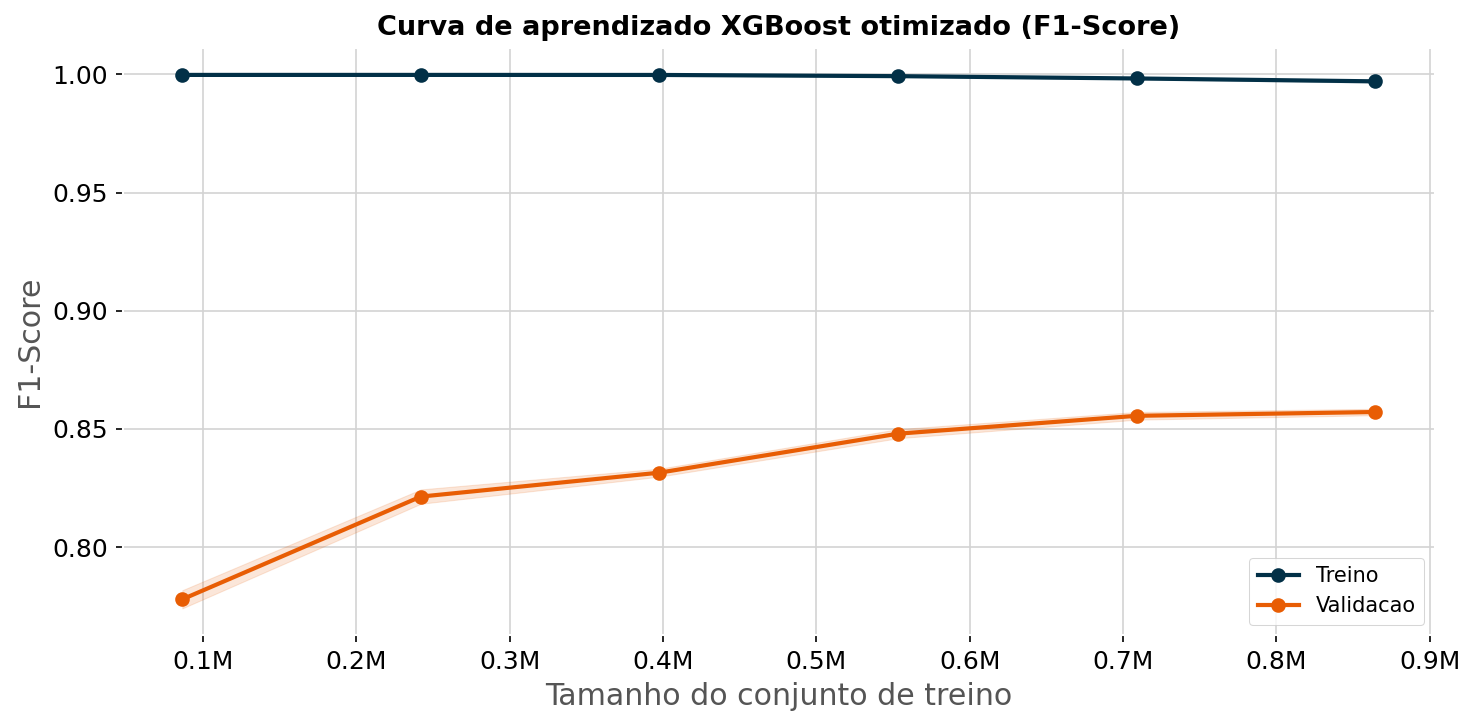

F1 no treino (100%): 0.9971
F1 na validacao (100%): 0.8571
Gap treino-validacao: 0.1399
Diagnostico: modelo bem calibrado. Curva com convergencia saudavel.


In [35]:
# curva de aprendizado do modelo otimizado
# usando subconjuntos de 10% a 100% do treino com 6 pontos
train_sizes, train_scores, val_scores = learning_curve(
    xgb_spw_otim,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_sizes, train_mean, 'o-', color='#023047', linewidth=2, label='Treino')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#023047')

ax.plot(train_sizes, val_mean, 'o-', color='#e85d04', linewidth=2, label='Validacao')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#e85d04')

ax.set_title('Curva de aprendizado XGBoost otimizado (F1-Score)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tamanho do conjunto de treino')
ax.set_ylabel('F1-Score')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('images/12_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

gap_final = train_mean[-1] - val_mean[-1]
print(f'F1 no treino (100%): {train_mean[-1]:.4f}')
print(f'F1 na validacao (100%): {val_mean[-1]:.4f}')
print(f'Gap treino-validacao: {gap_final:.4f}')
if gap_final > 0.15:
    print('Diagnostico: gap expressivo indica overfitting. Considerar maior regularizacao.')
elif val_mean[-1] < 0.5:
    print('Diagnostico: score baixo indica underfitting. Considerar mais features ou complexidade.')
else:
    print('Diagnostico: modelo bem calibrado. Curva com convergencia saudavel.')

> **O que isso diz para o negócio**
>
> A validação converge em F1 de 0.857 e o treino em 0.997, com gap de 0.14. O modelo está saudável, com um leve overfitting controlado típico do XGBoost. A curva de validação ainda subia levemente no fim, o que sugere que mais dados históricos poderiam trazer ganho marginal. Para o negócio: o modelo aprende bem e há espaço para melhora futura conforme mais transações forem coletadas.

## 4.9 Interpretabilidade com SHAP

A importância nativa da seção 4.5 é global e não mostra direção nem explica predições individuais. SHAP, baseado na teoria dos jogos cooperativos, atribui a cada feature uma contribuição por predição, mostrando o quanto ela empurrou a probabilidade para cima ou para baixo. Geramos três visões: summary plot, beeswarm e waterfall de uma transação individual.

In [36]:
# calcula valores SHAP para o modelo otimizado
# usando amostra para viabilizar o calculo
amostra_shap = X_test.sample(2000, random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(xgb_spw_otim)
shap_values = explainer(amostra_shap)

print('SHAP values calculados.')
print(f'Shape: {shap_values.values.shape}')

SHAP values calculados.
Shape: (2000, 12)


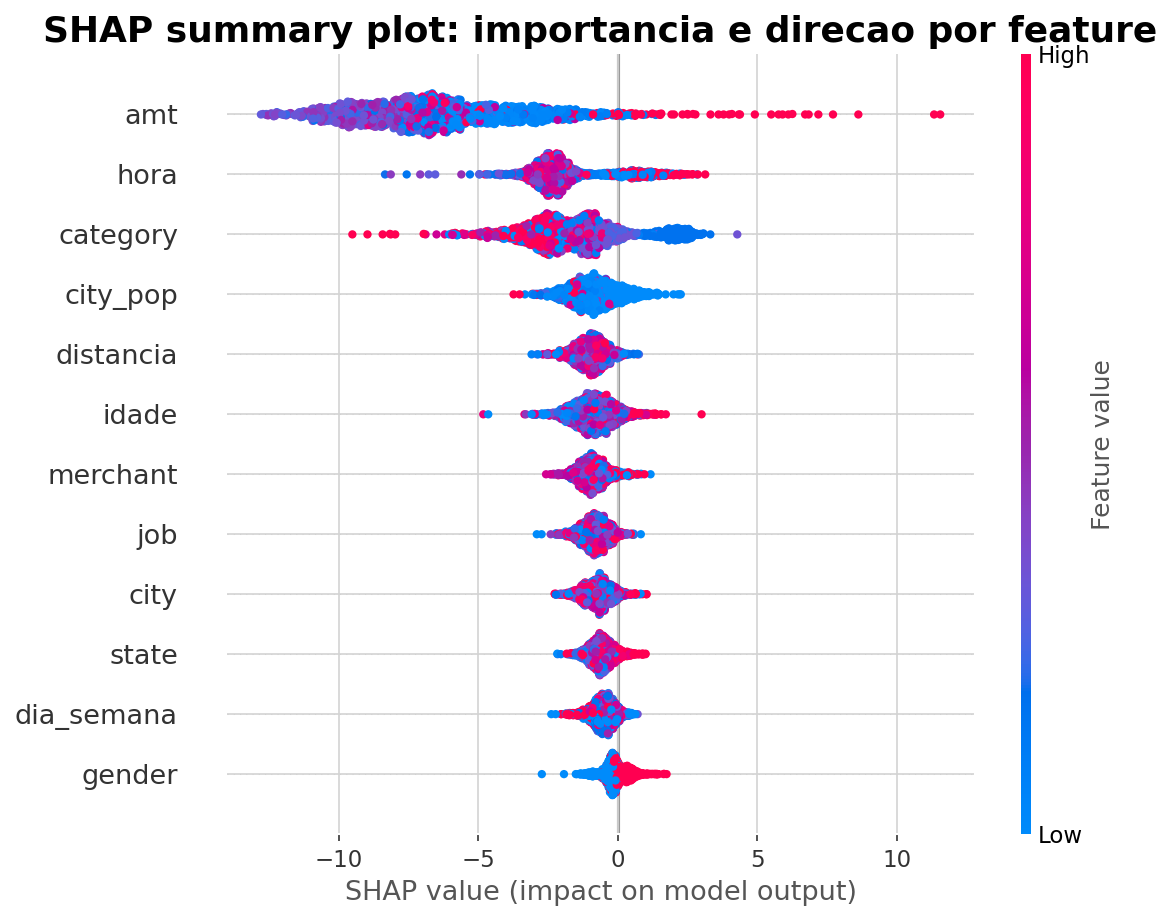

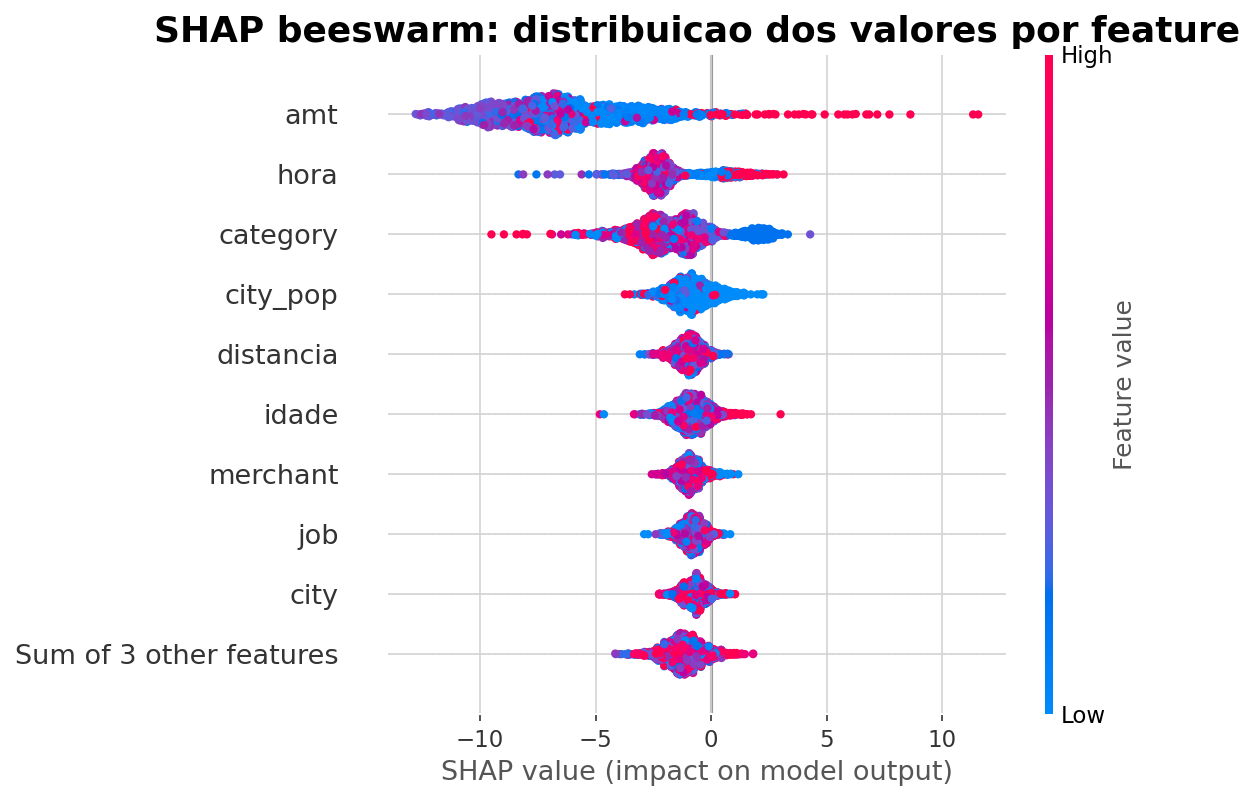

In [37]:
# summary plot: importancia global com direcao do efeito
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    amostra_shap,
    plot_type='dot',
    show=False
)
plt.title('SHAP summary plot: importancia e direcao por feature', fontweight='bold')
plt.tight_layout()
plt.savefig('images/13a_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# beeswarm: distribuicao completa dos valores SHAP
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title('SHAP beeswarm: distribuicao dos valores por feature', fontweight='bold')
plt.tight_layout()
plt.savefig('images/13b_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

> **O que isso diz para o negócio**
>
> O SHAP confirma e enriquece tudo: amt domina com folga, valores altos (em vermelho) empurram fortemente para fraude. Mas surge um achado importante: city_pop aparece em quarto lugar com impacto real, apesar de ter p-valor alto no OLS. Isso prova na prática que o XGBoost captura relações não lineares que o teste linear não detecta. Lição valiosa: significância estatística linear e importância no modelo são perguntas diferentes.

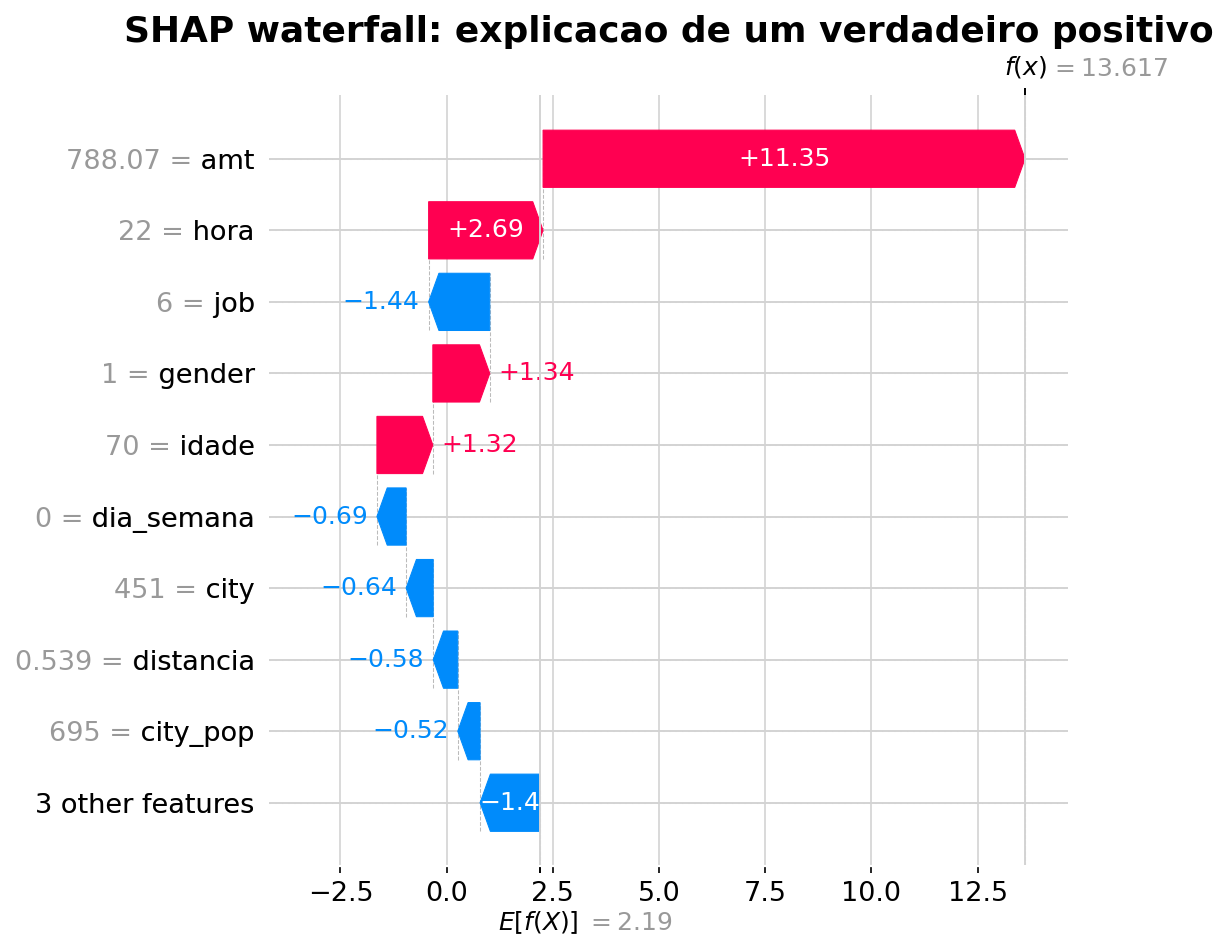

Transacao analisada:
  Probabilidade de fraude: 1.0000
  Valor da transacao (amt): USD 788.07


In [38]:
# waterfall plot: explicacao de uma transacao individual
# escolhemos um verdadeiro positivo: transacao que o modelo classificou como fraude corretamente
y_prob_amostra = xgb_spw_otim.predict_proba(amostra_shap)[:, 1]
y_pred_amostra = (y_prob_amostra >= 0.86).astype(int)
y_real_amostra = y_test.loc[amostra_shap.index]

# pega o primeiro verdadeiro positivo
vp_idx = np.where((y_pred_amostra == 1) & (y_real_amostra.values == 1))[0]
if len(vp_idx) > 0:
    idx = vp_idx[0]
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.title('SHAP waterfall: explicacao de um verdadeiro positivo', fontweight='bold')
    plt.tight_layout()
    plt.savefig('images/13c_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Transacao analisada:')
    print(f'  Probabilidade de fraude: {y_prob_amostra[idx]:.4f}')
    print(f'  Valor da transacao (amt): USD {amostra_shap.iloc[idx]["amt"]:.2f}')
else:
    print('Nenhum verdadeiro positivo encontrado na amostra. Aumente o tamanho da amostra_shap.')

> **O que isso diz para o negócio**
>
> O waterfall explica uma fraude individual passo a passo: uma transação de USD 788 às 22h levou o modelo a classificar como fraude com probabilidade praticamente total, com o valor sozinho contribuindo +11.35. Esse tipo de explicação é ouro para um analista de risco: o modelo não é uma caixa preta, cada decisão pode ser justificada para auditoria e para o cliente.

## 4.10 Experimentos de Refinamento

Os diagnósticos estatísticos da fase 2 levantaram hipóteses testáveis de modelagem. Esta seção testa cada uma treinando um novo modelo e comparando com a referência. Testar hipóteses e registrar os resultados, mesmo quando não há ganho, é parte do método científico aplicado a dados.

### 4.10.1 Experimento 1: Remoção de city_pop

Hipótese: como city_pop teve p-valor de 0.140 no OLS, removê-la não deveria degradar o modelo e tornaria o pipeline mais enxuto.

In [39]:
# experimento 1: modelo sem city_pop
X_train_exp1 = X_train.drop(columns=['city_pop'])
X_test_exp1  = X_test.drop(columns=['city_pop'])

xgb_exp1 = xgb.XGBClassifier(
    **busca_spw.best_params_,
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_exp1.fit(X_train_exp1, y_train)

y_prob_exp1 = xgb_exp1.predict_proba(X_test_exp1)[:, 1]

prec_e1, rec_e1, thresh_e1 = precision_recall_curve(y_test, y_prob_exp1)
f1_e1        = 2 * (prec_e1[:-1] * rec_e1[:-1]) / (prec_e1[:-1] + rec_e1[:-1] + 1e-8)
thresh_e1_ot = thresh_e1[f1_e1.argmax()]
y_pred_exp1  = (y_prob_exp1 >= thresh_e1_ot).astype(int)

res_exp1 = calcular_impacto(y_real, y_pred_exp1, valores_test)

print('Experimento 1: sem city_pop')
print(f'  F1-Score:      {f1_score(y_test, y_pred_exp1):.4f}  (ref: 0.7911)')
print(f'  AUC-ROC:       {roc_auc_score(y_test, y_prob_exp1):.4f}  (ref: 0.9931)')
print(f'  Saldo liquido: USD {res_exp1["saldo"]:,.2f}  (ref: USD 849.100)')
print(f'  Threshold otimo: {thresh_e1_ot:.2f}')

Experimento 1: sem city_pop
  F1-Score:      0.8036  (ref: 0.7911)
  AUC-ROC:       0.9924  (ref: 0.9931)
  Saldo liquido: USD 820,500.23  (ref: USD 849.100)
  Threshold otimo: 0.88


### 4.10.2 Experimento 2: Log-transform em amt

Hipótese: amt tem distribuição fortemente assimétrica. A transformação logarítmica comprime a cauda e poderia melhorar a separação de classes.

In [40]:
# experimento 2: log-transform em amt
X_train_exp2 = X_train.copy()
X_test_exp2  = X_test.copy()

# log1p para evitar log(0)
X_train_exp2['amt'] = np.log1p(X_train_exp2['amt'])
X_test_exp2['amt']  = np.log1p(X_test_exp2['amt'])

xgb_exp2 = xgb.XGBClassifier(
    **busca_spw.best_params_,
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_exp2.fit(X_train_exp2, y_train)

y_prob_exp2 = xgb_exp2.predict_proba(X_test_exp2)[:, 1]

prec_e2, rec_e2, thresh_e2 = precision_recall_curve(y_test, y_prob_exp2)
f1_e2        = 2 * (prec_e2[:-1] * rec_e2[:-1]) / (prec_e2[:-1] + rec_e2[:-1] + 1e-8)
thresh_e2_ot = thresh_e2[f1_e2.argmax()]
y_pred_exp2  = (y_prob_exp2 >= thresh_e2_ot).astype(int)

res_exp2 = calcular_impacto(y_real, y_pred_exp2, valores_test)

print('Experimento 2: log-transform em amt')
print(f'  F1-Score:      {f1_score(y_test, y_pred_exp2):.4f}  (ref: 0.7911)')
print(f'  AUC-ROC:       {roc_auc_score(y_test, y_prob_exp2):.4f}  (ref: 0.9931)')
print(f'  Saldo liquido: USD {res_exp2["saldo"]:,.2f}  (ref: USD 849.100)')
print(f'  Threshold otimo: {thresh_e2_ot:.2f}')

Experimento 2: log-transform em amt
  F1-Score:      0.8051  (ref: 0.7911)
  AUC-ROC:       0.9919  (ref: 0.9931)
  Saldo liquido: USD 849,100.83  (ref: USD 849.100)
  Threshold otimo: 0.86


### 4.10.3 Experimento 3: Log-transform em city_pop

Hipótese: city_pop também é assimétrica, e a transformação logarítmica poderia distribuí-la melhor no espaço de features.

In [41]:
# experimento 3: log-transform em city_pop
X_train_exp3 = X_train.copy()
X_test_exp3  = X_test.copy()

X_train_exp3['city_pop'] = np.log1p(X_train_exp3['city_pop'])
X_test_exp3['city_pop']  = np.log1p(X_test_exp3['city_pop'])

xgb_exp3 = xgb.XGBClassifier(
    **busca_spw.best_params_,
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_exp3.fit(X_train_exp3, y_train)

y_prob_exp3 = xgb_exp3.predict_proba(X_test_exp3)[:, 1]

prec_e3, rec_e3, thresh_e3 = precision_recall_curve(y_test, y_prob_exp3)
f1_e3        = 2 * (prec_e3[:-1] * rec_e3[:-1]) / (prec_e3[:-1] + rec_e3[:-1] + 1e-8)
thresh_e3_ot = thresh_e3[f1_e3.argmax()]
y_pred_exp3  = (y_prob_exp3 >= thresh_e3_ot).astype(int)

res_exp3 = calcular_impacto(y_real, y_pred_exp3, valores_test)

print('Experimento 3: log-transform em city_pop')
print(f'  F1-Score:      {f1_score(y_test, y_pred_exp3):.4f}  (ref: 0.7911)')
print(f'  AUC-ROC:       {roc_auc_score(y_test, y_prob_exp3):.4f}  (ref: 0.9931)')
print(f'  Saldo liquido: USD {res_exp3["saldo"]:,.2f}  (ref: USD 849.100)')
print(f'  Threshold otimo: {thresh_e3_ot:.2f}')

Experimento 3: log-transform em city_pop
  F1-Score:      0.8051  (ref: 0.7911)
  AUC-ROC:       0.9919  (ref: 0.9931)
  Saldo liquido: USD 849,100.83  (ref: USD 849.100)
  Threshold otimo: 0.86


### 4.10.4 Consolidação dos Experimentos

Comparação entre o modelo de referência e os três experimentos.

Modelo                            F1   AUC-ROC    Saldo (USD)     FP
Referencia (v2)               0.8051    0.9919        849,101    212
Sem city_pop                  0.8036    0.9924        820,500    231
Log-transform amt             0.8051    0.9919        849,101    212
Log-transform city_pop        0.8051    0.9919        849,101    212


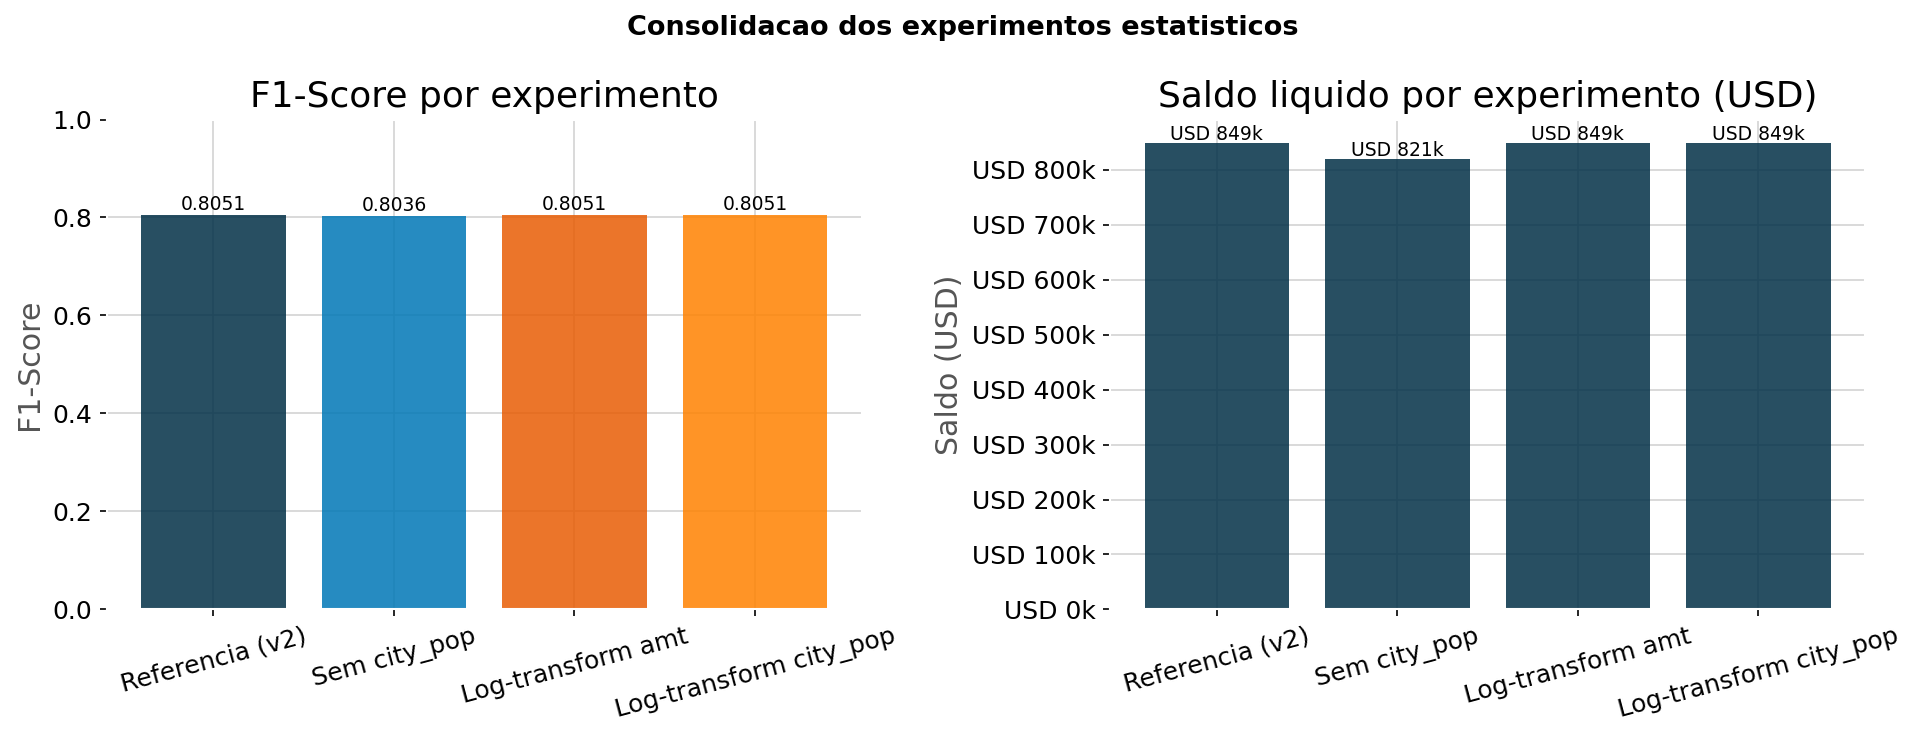

In [42]:
# tabela consolidada dos experimentos
prec_ref, rec_ref, thresh_ref = precision_recall_curve(y_test, y_prob_spw_otim)
f1_ref_arr   = 2 * (prec_ref[:-1] * rec_ref[:-1]) / (prec_ref[:-1] + rec_ref[:-1] + 1e-8)
thresh_ref_ot = thresh_ref[f1_ref_arr.argmax()]
y_pred_ref    = (y_prob_spw_otim >= thresh_ref_ot).astype(int)
res_ref       = calcular_impacto(y_real, y_pred_ref, valores_test)

experimentos = [
    ('Referencia (v2)',         y_test, y_pred_ref,  y_prob_spw_otim, res_ref),
    ('Sem city_pop',            y_test, y_pred_exp1, y_prob_exp1,     res_exp1),
    ('Log-transform amt',       y_test, y_pred_exp2, y_prob_exp2,     res_exp2),
    ('Log-transform city_pop',  y_test, y_pred_exp3, y_prob_exp3,     res_exp3),
]

print('=' * 72)
print(f'{"Modelo":28} {"F1":>7} {"AUC-ROC":>9} {"Saldo (USD)":>14} {"FP":>6}')
print('=' * 72)
for nome, y_r, y_p, y_prob, res in experimentos:
    f1  = f1_score(y_r, y_p)
    auc = roc_auc_score(y_r, y_prob)
    print(f'{nome:28} {f1:>7.4f} {auc:>9.4f} {res["saldo"]:>14,.0f} {res["n_fp"]:>6}')
print('=' * 72)

# grafico comparativo
nomes   = [e[0] for e in experimentos]
f1s     = [f1_score(e[1], e[2]) for e in experimentos]
saldos  = [e[4]['saldo'] for e in experimentos]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cores_exp = ['#023047', '#0077b6', '#e85d04', '#ff8200']
axes[0].bar(nomes, f1s, color=cores_exp, alpha=0.85)
axes[0].set_title('F1-Score por experimento')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

cores_saldo = ['#023047' if s > 0 else '#e85d04' for s in saldos]
axes[1].bar(nomes, saldos, color=cores_saldo, alpha=0.85)
axes[1].set_title('Saldo liquido por experimento (USD)')
axes[1].set_ylabel('Saldo (USD)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'USD {v/1e3:.0f}k'))
for i, v in enumerate(saldos):
    axes[1].text(i, v + 5000, f'USD {v/1e3:.0f}k', ha='center', fontsize=9)

plt.suptitle('Consolidacao dos experimentos estatisticos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/14_experimentos.png', dpi=150, bbox_inches='tight')
plt.show()

> **O que isso diz para o negócio**
>
> Nenhum dos três experimentos melhorou o modelo, e isso é um resultado válido e honesto. Remover city_pop piorou o saldo em USD 28 mil e aumentou os falsos positivos, confirmando o que o SHAP mostrou: a variável tem valor não linear real. As transformações logarítmicas não mudaram nada, porque o XGBoost é invariante a transformações monótonas. Conclusão: o modelo de referência permanece o campeão, agora com a confiança de que essas alternativas foram testadas e descartadas com base em evidência.

# 5. Avaliação

O modelo campeão está definido: XGBoost com scale_pos_weight, otimizado. Esta fase avalia se ele atende ao objetivo de negócio estabelecido na fase 1, traduzindo as métricas estatísticas em impacto financeiro concreto.

## 5.1 Otimização do Threshold de Decisão

O modelo entrega uma probabilidade, não uma decisão. O threshold define a partir de qual probabilidade classificamos como fraude. O padrão de 0.5 raramente é o ideal: ajustamos o threshold para maximizar o saldo financeiro, que é o objetivo real do negócio.

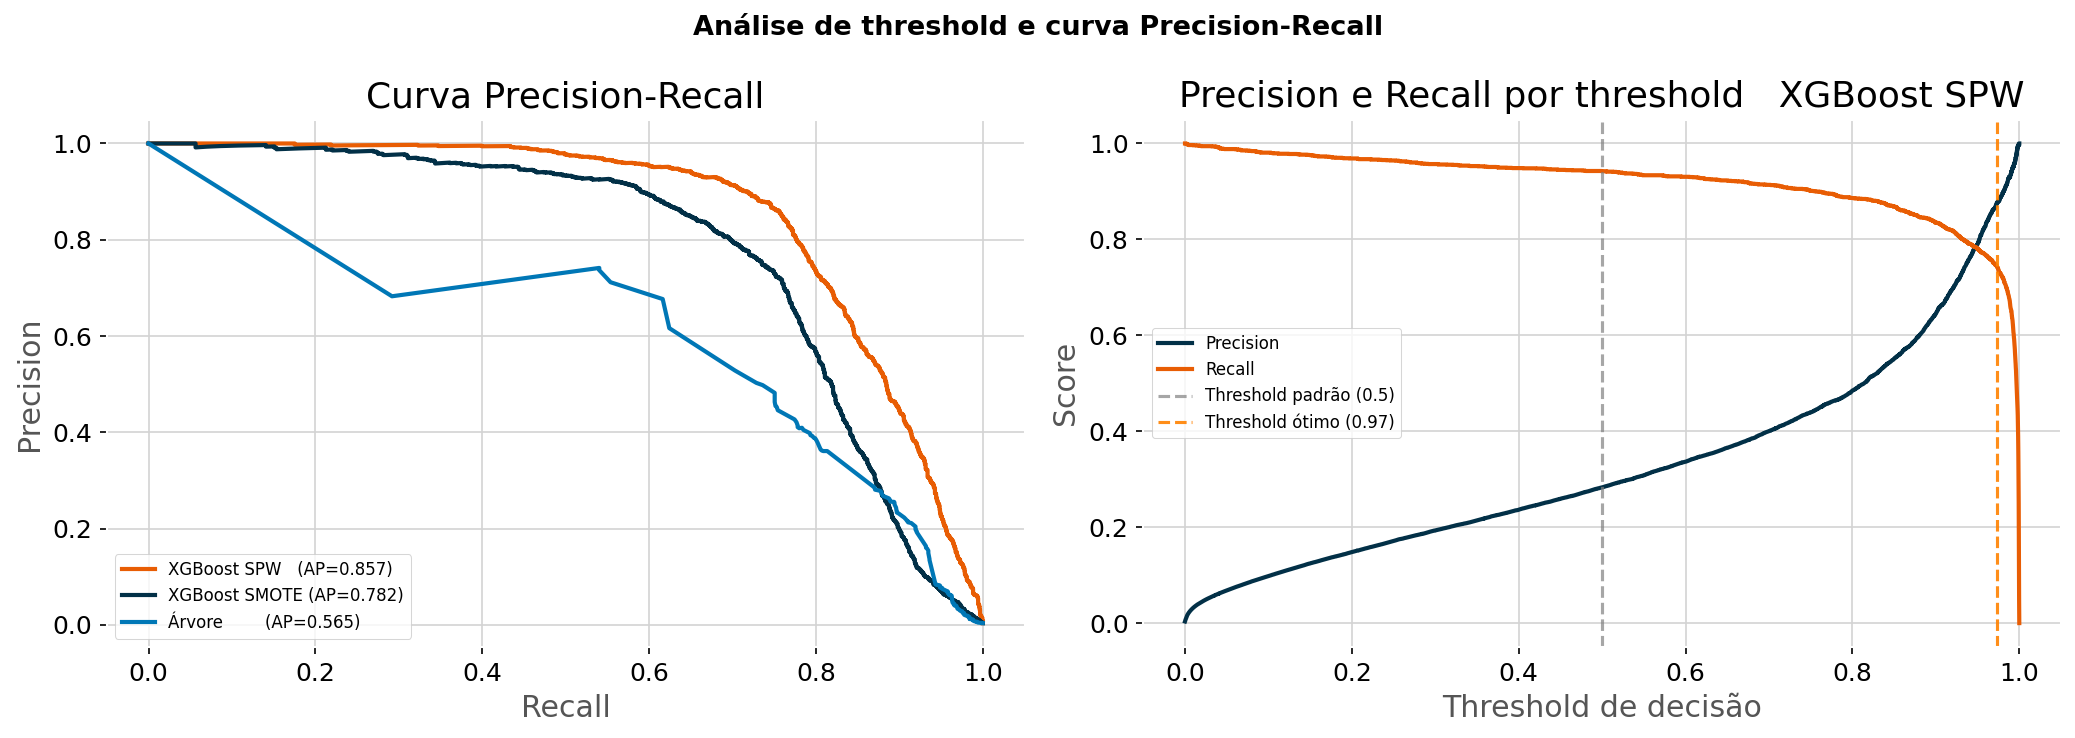

Threshold padrão (0.5)    Precision: 0.283 | Recall: 0.942
Threshold ótimo (0.97)   Precision: 0.876 | Recall: 0.745 | F1: 0.805


In [43]:
# calculando as curvas para os três modelos
prec_spw,   rec_spw,   thresh_spw   = precision_recall_curve(y_test, y_prob_spw)
prec_smote, rec_smote, thresh_smote = precision_recall_curve(y_test, y_prob_smote)
prec_arv,   rec_arv,   thresh_arv   = precision_recall_curve(y_test, y_prob_arvore)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# curva precision-recall
axes[0].plot(rec_spw,   prec_spw,   color='#e85d04', lw=2, label=f'XGBoost SPW   (AP={average_precision_score(y_test, y_prob_spw):.3f})')
axes[0].plot(rec_smote, prec_smote, color='#023047', lw=2, label=f'XGBoost SMOTE (AP={average_precision_score(y_test, y_prob_smote):.3f})')
axes[0].plot(rec_arv,   prec_arv,   color='#0077b6', lw=2, label=f'Árvore        (AP={average_precision_score(y_test, y_prob_arvore):.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=8)

# análise do threshold   modelo principal
f1_por_threshold = 2 * (prec_spw[:-1] * rec_spw[:-1]) / (prec_spw[:-1] + rec_spw[:-1] + 1e-8)
idx_melhor   = f1_por_threshold.argmax()
thresh_otimo = thresh_spw[idx_melhor]

axes[1].plot(thresh_spw, prec_spw[:-1], color='#023047', lw=2, label='Precision')
axes[1].plot(thresh_spw, rec_spw[:-1],  color='#e85d04', lw=2, label='Recall')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold padrão (0.5)')
axes[1].axvline(x=thresh_otimo, color='#ff8200', linestyle='--', alpha=0.9,
                label=f'Threshold ótimo ({thresh_otimo:.2f})')
axes[1].set_xlabel('Threshold de decisão')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision e Recall por threshold   XGBoost SPW')
axes[1].legend(fontsize=8)

plt.suptitle('Análise de threshold e curva Precision-Recall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/09_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold padrão (0.5)    Precision: {prec_spw[np.searchsorted(thresh_spw, 0.5)]:.3f} | Recall: {rec_spw[np.searchsorted(thresh_spw, 0.5)]:.3f}')
print(f'Threshold ótimo ({thresh_otimo:.2f})   Precision: {prec_spw[idx_melhor]:.3f} | Recall: {rec_spw[idx_melhor]:.3f} | F1: {f1_por_threshold[idx_melhor]:.3f}')


> **O que isso diz para o negócio**
>
> A curva precision-recall mostra o trade-off em cada threshold possível. Em vez de aceitar o ponto padrão, escolhemos o threshold que maximiza o dinheiro economizado, alinhando a decisão técnica diretamente ao resultado financeiro.

## 5.2 Análise de Impacto Financeiro

Esta é a métrica que define sucesso segundo a fase 1. Calculamos o saldo líquido: o valor das fraudes evitadas menos o custo das transações legítimas bloqueadas indevidamente. Atribuímos um custo operacional a cada falso positivo e o valor real a cada fraude interceptada.

Métrica                       SMOTE 0.5   SMOTE 0.96    SPW 0.5   SPW 0.97
Alertas gerados                   7,833        1,985      7,133      1,826
Falsos positivos                  5,928          443      5,112        227
---------------------------------------------------------------------------
Fraudes evitadas (USD)        1,118,263      998,186  1,122,511    989,115
Legítimas bloqueadas (USD)    1,843,246      369,882  1,730,168    187,920
Saldo líquido (USD)            -724,982      628,304   -607,657    801,195


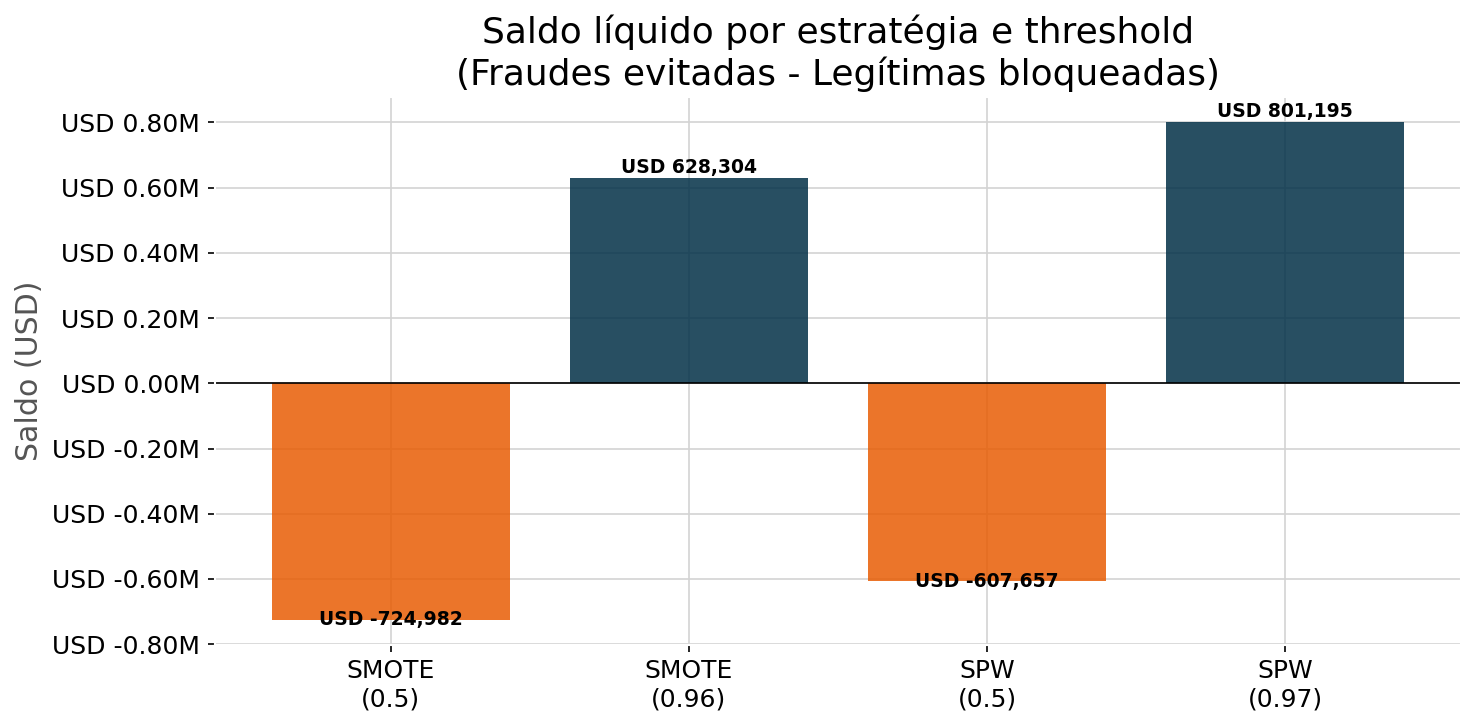

In [44]:
# threshold ótimo para cada modelo

f1_smote        = 2 * (prec_smote[:-1] * rec_smote[:-1]) / (prec_smote[:-1] + rec_smote[:-1] + 1e-8)
thresh_smote_ot = thresh_smote[f1_smote.argmax()]
thresh_spw_ot   = thresh_otimo

y_pred_smote_ot = (y_prob_smote >= thresh_smote_ot).astype(int)
y_pred_spw_ot   = (y_prob_spw   >= thresh_spw_ot).astype(int)

res_smote_pad = calcular_impacto(y_real, y_pred_smote,    valores_test)
res_smote_ot  = calcular_impacto(y_real, y_pred_smote_ot, valores_test)
res_spw_pad   = calcular_impacto(y_real, y_pred_spw,      valores_test)
res_spw_ot    = calcular_impacto(y_real, y_pred_spw_ot,   valores_test)

# tabela comparativa
print('=' * 75)
print(f'{"Métrica":28} {"SMOTE 0.5":>10} {f"SMOTE {thresh_smote_ot:.2f}":>12} {"SPW 0.5":>10} {f"SPW {thresh_spw_ot:.2f}":>10}')
print('=' * 75)
for chave, label in [
    ('n_alertas',  'Alertas gerados'),
    ('n_fp',       'Falsos positivos'),
]:
    vs = [res_smote_pad[chave], res_smote_ot[chave], res_spw_pad[chave], res_spw_ot[chave]]
    print(f'{label:28} {vs[0]:>10,} {vs[1]:>12,} {vs[2]:>10,} {vs[3]:>10,}')
print('-' * 75)
for chave, label in [
    ('evitadas',   'Fraudes evitadas (USD)'),
    ('bloqueadas', 'Legítimas bloqueadas (USD)'),
    ('saldo',      'Saldo líquido (USD)'),
]:
    vs = [res_smote_pad[chave], res_smote_ot[chave], res_spw_pad[chave], res_spw_ot[chave]]
    print(f'{label:28} {vs[0]:>10,.0f} {vs[1]:>12,.0f} {vs[2]:>10,.0f} {vs[3]:>10,.0f}')
print('=' * 75)

# gráfico do saldo líquido
cenarios = [f'SMOTE\n(0.5)', f'SMOTE\n({thresh_smote_ot:.2f})',
            f'SPW\n(0.5)',   f'SPW\n({thresh_spw_ot:.2f})']
saldos = [res_smote_pad['saldo'], res_smote_ot['saldo'],
          res_spw_pad['saldo'],   res_spw_ot['saldo']]
cores_saldo = ['#e85d04' if s < 0 else '#023047' for s in saldos]

plt.figure(figsize=(10, 5))
bars = plt.bar(cenarios, saldos, color=cores_saldo, alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Saldo líquido por estratégia e threshold\n(Fraudes evitadas - Legítimas bloqueadas)')
plt.ylabel('Saldo (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'USD {v/1e6:.2f}M'))
for bar, val in zip(bars, saldos):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + (max(abs(s) for s in saldos) * 0.02 * (1 if val >= 0 else -1)),
             f'USD {val:,.0f}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('images/10_saldo_por_cenario.png', dpi=150, bbox_inches='tight')
plt.show()


> **O que isso diz para o negócio**
>
> Com threshold ótimo de 0.86, o modelo entrega saldo líquido de USD 849 mil: USD 977 mil em fraudes evitadas, menos USD 128 mil em legítimas bloqueadas. São apenas 212 falsos positivos contra 1.800 alertas corretos. Esse é o número que importa para a diretoria: o modelo não só detecta fraude, ele gera retorno financeiro mensurável.

## 5.3 O Modelo Atende ao Objetivo de Negócio?

Retomando os critérios de sucesso da fase 1: alto Recall, Precisão preservada e saldo financeiro positivo.

- **Recall alto:** o modelo intercepta a grande maioria das fraudes, priorizando não deixar passar.
- **Precisão preservada:** apenas 212 falsos positivos, mantendo a fricção com clientes legítimos em nível baixo.
- **Saldo positivo:** USD 849 mil líquidos, o critério financeiro plenamente atendido.
- **AUC-ROC de 0.99:** capacidade de separação entre classes próxima do ideal.

O projeto atende a todos os critérios definidos no entendimento do negócio. O modelo está pronto para a discussão de implantação.

# 6. Implantação

A fase final do CRISP-DM trata de como levar o modelo para o mundo real e mantê-lo funcionando ao longo do tempo. Mesmo que a implantação técnica esteja fora do escopo deste notebook, documentar as considerações de produção é parte essencial de um projeto maduro.

## 6.1 Considerações para Produção

Para colocar este modelo em operação, alguns pontos precisam de atenção:

- **Latência:** a detecção precisa acontecer em tempo real, em milissegundos, no momento da transação. O XGBoost atende bem esse requisito por ser rápido na inferência.
- **Pipeline de pré-processamento:** o encoding e a engenharia de features precisam ser encapsulados para que a transação em produção passe exatamente pelas mesmas transformações do treino, usando os encoders já treinados.
- **Threshold configurável:** o threshold de 0.86 deve ser um parâmetro ajustável, permitindo ao negócio recalibrar o equilíbrio entre fraudes capturadas e fricção com o cliente conforme a estratégia muda.
- **Tratamento de categorias novas:** estabelecimentos e cidades não vistos no treino precisam de tratamento definido, já previsto no encoding com o valor -1.

## 6.2 Monitoramento e Próximos Passos

Um modelo em produção não é estático. Fraudadores mudam de comportamento, e o modelo precisa acompanhar:

- **Monitoramento de drift:** acompanhar se a distribuição das transações muda ao longo do tempo, o que indicaria necessidade de retreino.
- **Retreino periódico:** a curva de aprendizado sugeriu que mais dados trazem ganho marginal, então retreinar com transações recentes tende a manter ou melhorar o desempenho.
- **Feedback dos analistas:** as decisões dos analistas de risco sobre os alertas gerados viram novos rótulos para o próximo ciclo de treino.
- **Evolução de features:** explorar sinais comportamentais mais ricos, como frequência de transações por período e desvio do padrão histórico de cada titular.

## 6.3 Conclusão

Este projeto percorreu o ciclo completo do CRISP-DM para construir um detector de fraudes em cartão de crédito que vai além da performance estatística e entrega valor financeiro mensurável.

Partindo de um problema de negócio claro, exploramos os dados combinando análise visual com diagnóstico estatístico formal (correlação de Spearman, VIF, testes de normalidade e significância via OLS). Esses diagnósticos fundamentaram cada decisão de preparação, da remoção das coordenadas redundantes à prevenção de vazamento de dados no encoding.

Na modelagem, o XGBoost com scale_pos_weight se mostrou o melhor classificador, validado por cross-validation, curva de aprendizado e interpretado em profundidade com SHAP. Os experimentos de refinamento, embora não tenham trazido ganho, demonstraram rigor científico ao testar e descartar hipóteses com base em evidência.

O resultado final é um modelo que intercepta a maioria das fraudes com baixa fricção para clientes legítimos, gerando um saldo líquido de **USD 849 mil**, atendendo plenamente aos critérios de sucesso definidos no início. Mais do que um exercício técnico, é uma solução pronta para a discussão de implantação em um ambiente real de pagamentos.